<a href="https://colab.research.google.com/github/vinechai/sreality_EDA/blob/main/sreality_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Data preparation, model estimation

### 1. Setting up environment

#### 1.1 Importing packages & setting-up parameters

#### 1.2 Starting project timer and exporting requirements

#### 1.3 Importing and inspecting source data

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

In [ ]:

import pandas as pd
# data = pd.read_csv('updated_apartments_praha.csv')


# Provide the full path to the file in Google Drive
file_path = '/content/drive/My Drive/Colab Notebooks/updated_apartments_praha.csv'

# Load the CSV file using pandas
# data = pd.read_csv(file_path)

data_raw = pd.read_csv(file_path)  # load original
data = data_raw.copy()  # working dataset

In [ ]:
#set max columns and rows
pd.set_option('display.max_columns', data.shape[1])
pd.set_option('display.max_rows', None)

In [ ]:
print(type(data))

In [ ]:
data.head()

In [ ]:
data.Price.value_counts()

In [ ]:
print(data.info())

#### 1.4 Inspecting missing values

In [ ]:
missing_values = data.isnull().sum()*100/len(data)

In [ ]:
missing_values[missing_values > 0].sort_values(ascending = False).round(2)

In [ ]:
# conda install -c conda-forge/label/gcc7 missingno

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt
msno.matrix(data, sparkline=False, fontsize=20)
plt.show()

### 2. Data Cleansing and Transformation



In [ ]:
# Print basic info about variable - % of missing, # of unique values, unique values in data
for var in data.columns:
    valueCounts = pd.concat([data[var].value_counts(),
                data[var].value_counts(normalize=True).mul(100)],axis=1, keys=('counts', 'percentage'))
    print(var,'\n',len(data[var].unique()), 'unique values: ')
    display(valueCounts)

#### 2.1 Column Name Cleaning

In [ ]:
# Clean column names by converting to lowercase, replacing spaces, and stripping any leading/trailing spaces
data.columns = data.columns.str.lower().str.replace(' ', '_').str.strip()


#### 2.2 Target Column Transformation

In [ ]:
# 2.2.2 Target column transformation

import numpy as np

# let's drop 'price' column which doesn't have any relevant info
data = data.drop(columns=['price'])

# Change the name of the target column 'price_(czk)' to just 'price'
data = data.rename(columns={'price_(czk)': 'price'})

# Replace 'Information about price at agency' with NaN
data['price'] = data['price'].replace('Information about price at agency', np.nan)

# Change data type to numeric
data['price'] = pd.to_numeric(data['price'], errors='coerce')

In [ ]:
data.price.dtype

In [ ]:
data['price'][0]

In [ ]:
data.head()

In [ ]:
data['price'].isna().mean()

In [ ]:
data['price'].isna().sum()

In [ ]:
data[data['total_price'].isna()]

### 2.3 Remove Irrelevant Columns

Columns to fix.

remove:

*   link
*   total price (price is in 'price' column)
*   order id
*   update
*   move-in-date
*   loft (all na), elevator (all na), Barrier-free access , basin,                        
* telecommunications ???
* road ???
* note_on_the_price ???
* id
* visit_site_date
* visit_site_date_to
* status
* number_of_owners
* starting_price ??? ( only 2 values), expert_judgement (2 values), minimum_bid (same), auction_principal, type_of_auction , venue_auction, auction_sale_date , auction_sale_date, advertisement_of_auction
* 1st_site_visit_date, 	2nd_site_visit_date
* number_of_flats ???
* share_size_of_common_area?






*   List item


basic data transform:
* usable area, floorage, balcony
* gas - binary??
* furnished - binary
* terrace, cellar, energy_performance_indicator, garden_area, loggia , built-up_area, discounted, original_cost
* parking ???
* cost_of_living
* acquisition_of_title - binary
* sales_commencement_date - date
* ceiling_height (also check outliers)






fix:


*   building - combine Stone, Prefab, Wooden and Modular into one category 'Other' since those categories are rare and have very low counts (2, 3, 6, and 7)
*  property_status
* floor
* energy_performance_rating



remove later:
*   location


In this step, we remove columns from the dataset that are irrelevant, contain excessive missing values, or do not contribute meaningfully to our predictive modeling. Here is the rationale for each category of columns removed:

- Columns irrelevant to flat price prediction: Columns such as link, order_id, update, move-in_date, note_on_the_price, id, visit_site_date, visit_site_date_to, status, number_of_owners, 1st_site_visit_date, and 2nd_site_visit_date are administrative or logistical details that are unrelated to property pricing and do not provide valuable information for model training.

- Columns with only NA values: Columns loft, elevator, barrier-free access, and basin contain only NA values across all entries and thus provide no information for analysis.

- Columns likely irrelevant due to location: Since all listings are within Prague, major infrastructure and amenities such as telecommunications and road are consistently available and do not vary meaningfully across listings. As a result, they are unlikely to influence pricing and will be removed.

- Columns likely containing data entry errors: The number_of_flats column includes values that appear inconsistent with realistic values for individual flat listings (e.g., "30" flats in a single entry), suggesting it is likely a data entry error. We exclude this column to avoid introducing noise.

- Columns specific to auction listings: Columns related to auctions (starting_price, expert_judgement, minimum_bid, auction_principal, type_of_auction, venue_auction, auction_sale_date, advertisement_of_auction) are specific to only two listings in the dataset. Including these specialized columns would add unnecessary sparsity without significantly enhancing our model's performance, so they are removed.

In [ ]:
# Archive any essential columns before removing for possible future reference
reference_info = data[['location', 'size', 'price', 'link']].copy()

In [ ]:
# Columns to be dropped
columns_to_drop = [
    'link', 'order_id', 'update', 'move-in_date', 'note_on_the_price', 'id',
    'visit_site_date', 'visit_site_date_to', 'status', 'number_of_owners',
    '1st_site_visit_date', '2nd_site_visit_date', 'loft', 'elevator',
    'barrier-free_access', 'basin', 'telecommunications', 'road', 'number_of_flats',
    'starting_price', 'expert_judgement', 'minimum_bid', 'auction_principal',
    'type_of_auction', 'venue_auction', 'auction_sale_date', 'advertisement_of_auction',
    'original_cost'
]

# Dropping the columns from the DataFrame
data = data.drop(columns=columns_to_drop)


In [ ]:
data.head()

In [ ]:
from IPython.display import display, HTML

# Print basic info about variables: % of missing, # of unique values, unique values in data
for var in data.columns:
    dtype = data[var].dtype  # Get the data type of the column
    value_counts = pd.concat(
        [data[var].value_counts(dropna=False),
         data[var].value_counts(normalize=True, dropna=False).mul(100)],
        axis=1, keys=('counts', 'percentage')
    )
    # Print variable name with data type and number of unique values
    print(f"\n\n{'='*40}\n{var} (dtype: {dtype}) - {len(data[var].unique())} unique values\n{'='*40}")

    # Display the table with counts and percentages
    display(HTML(value_counts.to_html()))


### 2.4 Basic Data transofrmation

#### 2.4.1 Dtype correction






dtype correction: total_price - (czk per property, czk per property (k jednani)), floor ?? (2. floor of total 4 including 1 underground, -1. floor), usable area (m2), floorage, balcony (m2), electricity ?? (V. 120 V, 230 V, 400 V), energy_performance_certificate	(boolean), furnished (boolean), terrace (m2), cellar (m2), energy_performance_indicator (76.0 kWh/m^2 /year), garden area (m2), cost_of_living - probably remove, loggia (m2), reconstruction_year - float to int, garage - float to int, annuity - kc or remove???,
acquisition_of_title - boolean and what is it?,    final_building_approval_year - float to int, built-up_area - m2, construction_completion_date - to date but maybe remove, discounted - 10 500 000 CZK per property but maybe remove,
original_cost - czk but maybe remove, sales_commencement_date - to date, but maybe remove, basin_area - remove?,

2.4.1.1 total_price column. We should get read of 'CZK per property' and 'CZK per property (k jednání)', and also this one - 12 655 000 CZK (500 000 EUR) per property

In [ ]:
data['total_price_cleaned'] = (
    data['total_price']
    .str.extract(r'([\d\s]+) CZK')[0]  # Extract only the CZK price
    .str.replace(r'\s', '', regex=True)  # Remove spaces within the number
    .astype(float)  # Convert to numeric
)


In [ ]:
# same transofrmation for 'discounted' column
data['discounted'] = (
    data['discounted']
    .str.extract(r'([\d\s]+) CZK')[0]  # Extract only the CZK price
    .str.replace(r'\s', '', regex=True)  # Remove spaces within the number
    .astype(float)  # Convert to numeric
)

Now let's compare it to the 'price' column and see if there're any differences between them and which column should we drop.

In [ ]:
# Drop rows where 'price' or 'total_price_cleaned' is NaN
data_cleaned = data.copy()
data_cleaned = data_cleaned.dropna(subset=['price', 'total_price_cleaned'])

# Compare the two columns and identify mismatches
mismatched_rows = data_cleaned['price'] != data_cleaned['total_price_cleaned']

# Analyze mismatched rows
if mismatched_rows.sum() == 0:
    print("No differences found between 'price' and 'total_price_cleaned'.")
else:
    # Create a 'difference' column for easier analysis
    data_cleaned['difference'] = data_cleaned['total_price_cleaned'] - data_cleaned['price']

    # Output summary of mismatched rows
    print(f"There are {mismatched_rows.sum()} mismatched rows.")
    print("Summary of differences:")
    print(data_cleaned.loc[mismatched_rows, ['price', 'total_price_cleaned', 'difference']])


Observations:
1. Total Price Lower: In some cases, total_price_cleaned is lower than price. This could reflect:

- Adjustments made for discounts or negotiations.
- Exclusion of additional fees or costs that were included in the initial price.

2. Total Price Higher: In other cases, total_price_cleaned is higher. This might account for:

- Additional costs, such as VAT, real estate agency fees, or parking.
- Corrections to reflect the true advertised price.

3. Differences are Minor for Many Entries: For some rows, differences are as small as 1,000–50,000 CZK, which may represent rounding issues or minor edits in the listings.

4. Significant Discrepancies: There are a few extreme outliers where the difference is in the millions. These could indicate:

- Errors in data scraping or manual entry in the listings (one of the entries misses a digit in a 'price' column, so the difference between columns is 800%)


Choose price as Target:

- total_price_cleaned has around 15% of missing values, while price column has 5%. Since the differences between the columns are quite minimal the amount of missing values becomes a decisive factor for chosing target variable.

We need to drop 'total_price_cleaned' and 'total_price' columns

In [ ]:
# Extreme outliers
# Calculate the percentage difference
data_cleaned['percentage_difference'] = (
    (data_cleaned['total_price_cleaned'] - data_cleaned['price']) / data_cleaned['price']
) * 100

# Filter rows with absolute percentage difference > 10%
outliers = data_cleaned[abs(data_cleaned['percentage_difference']) > 15]
# Display all columns for these outliers
outliers

In [ ]:
outliers['percentage_difference']

Summary of Findings
1. Majority of Differences Below 10%:

The majority of the differences are less than or equal to 10%, which likely indicates consistency in the data for most rows. This threshold can be used as a general guideline for data quality.

2. A Few Rows Between 10%-20%:

Differences in this range might reflect genuine pricing discrepancies or market-driven variability. For instance, the 20.8% difference for a flat priced at ~2.4M could suggest a minor adjustment in the calculated total price.

3. Extreme Outlier at 900%:

The row with a 900% difference is a clear data entry error, where the price column is likely missing a digit.

4. Moderate Outlier at 27%:

The 27% difference in a flat priced at ~6M may warrant further investigation. It could stem from additional features, misclassification, or a systematic adjustment.


Now lets drop price and total_price_cleaned Columns:
This removes redundancy after confirming that the new price column (total_price_cleaned) is clean and complete.

Rename the Cleaned Price Column:
Renaming total_price_cleaned to price keeps it concise and avoids confusion.

Rearrange the Columns:
Move the new price column to the beginning.

In [ ]:
# Correct the specific case where price is missing a digit
def correct_price_outlier(data, index, factor=10):
    """
    Corrects the price value for a specific index by multiplying it by a given factor.
    """
    data.loc[index, 'price'] *= factor

# Identify rows with significant discrepancies
def identify_discrepancies(data, threshold=0.15):
    """
    Identifies rows where the relative difference between price and total_price exceeds the threshold.
    """
    diff_percentage = (data['price'] - data['total_price_cleaned']) / data['total_price_cleaned'] * 100
    outliers = diff_percentage.abs() > threshold * 100
    return data[outliers], diff_percentage

# Apply corrections and drop rows with unexplained differences
def clean_price_discrepancies(data, threshold=0.15, correction_indices=None):
    """
    Cleans price discrepancies in the dataset.
    """
    # Correct specific errors
    if correction_indices:
        for idx in correction_indices:
            correct_price_outlier(data, idx)

    # Identify rows with large discrepancies
    discrepancies, diff_percentage = identify_discrepancies(data, threshold)

    # Drop rows with unexplained differences
    data = data.drop(discrepancies.index)

    return data


# Step 1: Identify discrepancies
discrepancies, diff_percentage = identify_discrepancies(data, threshold=0.15)
#print(discrepancies)  # Inspect discrepancies manually

# Step 2: Define correction indices (after manual review)
correction_indices = [2760]  # Index with a clear, fixable error

# Step 3: Clean data
data = clean_price_discrepancies(data, threshold=0.15, correction_indices=correction_indices)

# Step 4: Drop the total_price and total_price_cleaned column
data = data.drop(columns=['total_price_cleaned', 'total_price'], errors='ignore')

# Move the 'price' column to the beginning
cols = ['price'] + [col for col in data.columns if col != 'price']
data = data[cols]

In [ ]:
discrepancies

In [ ]:
# Move the 'price' column to the beginning
cols = ['price'] + [col for col in data.columns if col != 'price']
data = data[cols]

## Updating Prices with Discounts in the Dataset

### Purpose
In this dataset, there are two columns related to price:
- `price`: The original price of the product.
- `discounted`: The discounted price of the product, if applicable.

The goal is to ensure that:
1. Wherever a discounted price exists (`discounted` column is not null), it is used as the final price.
2. The `price` column is updated with the discounted value, replacing the original price.
3. The `discounted` column is dropped after its values have been incorporated into `price`.


In [ ]:
def update_prices_with_discount(data):
    """
    Updates the 'price' column with values from the 'discounted' column wherever 'discounted' is not null.
    Prints each replacement for logging purposes and drops the 'discounted' column after the update.

    Parameters:
        data (pd.DataFrame): The DataFrame containing 'price' and 'discounted' columns.

    Returns:
        pd.DataFrame: The updated DataFrame with 'price' corrected and 'discounted' column removed.
    """
    # Iterate through rows where 'discounted' is not null
    for index, row in data[data['discounted'].notna()].iterrows():
        original_price = row['price']
        discounted_price = row['discounted']

        # Replace the 'price' with 'discounted'
        data.at[index, 'price'] = discounted_price

    # Drop the 'discounted' column
    data = data.drop(columns=['discounted'])

    return data

data = update_prices_with_discount(data)

In [ ]:
data.head()

2.4.1.2 'floor' column

In [ ]:
data['floor'].value_counts()

In [ ]:
import re


def extract_floor_info(floor_text):
    if not isinstance(floor_text, str):
        return None, None  # Return None for both if it's not a string

    # Handle "ground floor"
    if "ground floor" in floor_text.lower():
        floor_number = 0
    else:
        # Extract floor number before "floor"
        match = re.search(r"(\d+)\.?\s*floor", floor_text.lower())
        floor_number = int(match.group(1)) if match else None

    # Extract total floors
    total_match = re.search(r"total\s+(\d+)", floor_text.lower())
    total_floors = int(total_match.group(1)) if total_match else None

    return floor_number, total_floors

data[['floor_number', 'total_floors']] = data['floor'].apply(
    lambda x: pd.Series(extract_floor_info(x))
)


In [ ]:
data['floor_number'].value_counts(dropna = False)

In [ ]:
data = data.drop(columns = 'floor', errors='ignore')

In [ ]:
m = re.match(r"(\w+) (\w+), (\w+)", "Isaac Newton, physicist")

In [ ]:
m.group(3)

2.4.1.3 remove m2 - usable area, floorage, balcony (m2), terrace (m2), cellar (m2),garden area (m2), loggia (m2), built-up_area - m2, energy_performance_indicator

In [ ]:

#data['floorage'] = (
#    data['floorage']
#    .str.extract(r'([\d\s]+) m2')
#    .astype(float)  # Convert to numeric
#)


In [ ]:
data[['usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'loggia', 'built-up_area']].head(20)

In [ ]:
def remove_m2(data, columns):
    """
    Cleans column(s) by extracting numeric values and removing 'm2' suffix.

    Parameters:
    ----------
    data : pd.DataFrame
        The input DataFrame containing the column(s) to process.
    columns : str or list of str
        The name(s) of the column(s) to clean.

    Returns:
    -------
    pd.DataFrame
        The DataFrame with the cleaned column(s).
    """
    if isinstance(columns, str):
        columns = [columns]  # Convert single column to a list for consistency

    for column in columns:
        if column not in data.columns:
            raise KeyError(f"Column '{column}' does not exist in the DataFrame.")

        try:
            data[column] = (
                data[column]
                .str.extract(r'([\d\s]+)')  # Extract numbers and spaces
                .astype(float)             # Convert to float
            )
        except Exception as e:
            raise ValueError(f"Error processing column '{column}': {e}")

    return data

In [ ]:
def fillna_columns(data, columns, fill_value=0):
    """
    Fills missing values in the specified columns.

    Parameters:
    ----------
    data : pd.DataFrame
        The input DataFrame to process.
    columns : str or list of str
        The name(s) of the column(s) to process.
    fill_value : scalar, optional
        The value to use for filling missing data (default is 0).

    Returns:
    -------
    pd.DataFrame
        The DataFrame with updated column(s).
    """
    if isinstance(columns, str):
        columns = [columns]

    for column in columns:
        if column not in data.columns:
            raise KeyError(f"Column '{column}' does not exist in the DataFrame.")
        data[column] = data[column].fillna(fill_value)

    return data

def convert_to(data, columns, dtype):
    """
    Converts specified columns to a given dtype.

    Parameters:
    ----------
    data : pd.DataFrame
        The DataFrame containing the columns.
    columns : list of str
        The names of the columns to convert.
    dtype : type or str
        The data type to which the columns should be converted (e.g., 'Int64', float, str).

    Returns:
    -------
    pd.DataFrame
        The DataFrame with updated column(s).
    """
    if isinstance(columns, str):
        columns = [columns]

    for column in columns:
        if column not in data.columns:
            raise KeyError(f"Column '{column}' does not exist in the DataFrame.")
        data[column] = data[column].astype(dtype)

    return data


In [ ]:
'''
def fillna_and_cast(data, columns, fill_value=0, dtype=int):
    """
    Fills missing values and casts the specified column(s) to a given data type.

    Parameters:
    ----------
    data : pd.DataFrame
        The input DataFrame to process.
    columns : str or list of str
        The name(s) of the column(s) to process.
    fill_value : scalar, optional
        The value to use for filling missing data (default is 0).
    dtype : type, optional
        The target data type for casting (default is int).

    Returns:
    -------
    pd.DataFrame
        The DataFrame with updated column(s).
    """
    if isinstance(columns, str):
        columns = [columns]  # Convert single column to a list for consistency

    for column in columns:
        if column not in data.columns:
            raise KeyError(f"Column '{column}' does not exist in the DataFrame.")

        try:
            data[column] = data[column].fillna(fill_value).astype(dtype)
        except Exception as e:
            raise ValueError(f"Error processing column '{column}': {e}")

    return data
'''

In [46]:
data['usable_area']

In [ ]:
# Columns that need `remove_m2`
# WHY I DON'T REMOVE M2 FOR USABLE_AREA AND FLOORAGE and BUILT-UP_AREA???
columns_to_remove_m2 = ['usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'loggia', 'built-up_area', 'energy_performance_indicator', 'basin_area']
#columns_to_clean = ['balcony', 'terrace', 'cellar', 'garden_area', 'loggia', 'basin_area']

# Columns that need filling and typecasting (inclusive of `parking`)
# Features where NaN means "does not exist" → replace with 0 (fillna_columns)
to_exclude = ['usable_area', 'floorage', 'built-up_area', 'energy_performance_indicator'] # we exclude columns where 0 doesn't mean absense, so we rather leave NaN instead of filling up with 0s.
columns_to_fillna_and_cast = [col for col in columns_to_remove_m2 if col not in to_exclude]
columns_to_fillna_and_cast += ['parking', 'garage']

data = remove_m2(data, columns_to_remove_m2)
data = fillna_columns(data, columns_to_fillna_and_cast)
#data = convert_to(data, columns_to_fillna_and_cast, 'int64')


In [48]:
data[['usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'loggia', 'built-up_area', 'energy_performance_indicator']].head(20)

2.4.1.4 Drop columns
'electricity' column drop - more than half of the values are NaN, the column doesn’t significantly influence price, for residential properties, multiple voltage options don't influence price significantly.

cost_of_living column has 94% Nan

drop rows:
annuity - in some cases annuity is included in the price, in some - not, and it's difficult to determine if annuity included in the price or not, especially when annuity is not large. Therefore it's difficult to ensure the integrity of the target variable (price). We prioritize data clarity and model integrity over marginal data retention, so it makes sense to drop the rows that include annuity, especially since there're only 89 rows (less then 2%).

The "acquisition_of_title" column was removed due to its high percentage of missing values (95%), lack of clear relevance to price prediction, and the potential for introducing noise into the model.

sales_commencement_date - 92 % of missing values, lack of clear relevance to price prediction

drop discounted and original_price column since we'd just keep the final price as a target variable and only 2% of 'discounted' values are not nan

drop basin_area column since there's only 1 value making it statistically insignificant for model training


drop rows
that don't have price in 'price' column. Supervised Learning Requirement: Predictive modeling for price requires target values. Rows without prices provide no learning signal for the model.
Imputation Challenge: Imputing price values for rows with no strong contextual predictors (like basin area or other missing columns) could introduce bias or error.



2.4.1.5 Boolean columns = 'energy_performance_certificate' has only one value - "Open Energy Performance Certificate", 'furnished' column also has one column 'Partially', so we can convert those collumns to boolean.

In [ ]:
def convert_to_boolean(data, column, true_value=None):
    """
    Converts a column to boolean (1, 0).

    Args:
        data (pd.DataFrame): The DataFrame to process.
        column (str): The column name.
        true_value (str, optional): The value to consider as True (1). If None, any non-NaN value is considered True.

    Returns:
        pd.DataFrame: DataFrame with the column converted to boolean.
    """
    try:
        if true_value is None:
            data[column] = data[column].notna().astype(int)
        else:
            data[column] = data[column].apply(lambda x: 1 if x == true_value else 0)
        return data
    except KeyError:
        raise KeyError(f"Column {column} does not exist in the DataFrame.")


In [ ]:
# Convert energy_performance_certificate
data = convert_to_boolean(data, 'energy_performance_certificate')

# Convert furnished
data = convert_to_boolean(data, 'furnished')


2.4.1.6 Convert reconstruction_year, final_building_approval_year99 and garage columns to integer. Also consider to drop reconstruction_year later, since it has 92% of missing values.

In [ ]:
def convert_to(data, columns, dtype):
    """
    Converts specified columns to a given dtype.

    Parameters:
    ----------
    data : pd.DataFrame
        The DataFrame containing the columns.
    columns : list of str
        The names of the columns to convert.
    dtype : type or str
        The data type to which the columns should be converted (e.g., 'Int64', float, str).

    Returns:
    -------
    pd.DataFrame
        The DataFrame with updated column(s).
    """
    if not isinstance(columns, list):
        raise TypeError("`columns` should be a list of column names.")

    for column in columns:
        if column not in data.columns:
            raise KeyError(f"Column '{column}' does not exist in the DataFrame.")
        try:
            data[column] = data[column].astype(dtype)
        except Exception as e:
            raise ValueError(f"Could not convert column '{column}' to type {dtype}: {e}")

    return data

# Example Usage:
columns_to_convert = ['reconstruction_year', 'final_building_approval_year']
data = convert_to(data, columns_to_convert, 'Int64')



In [ ]:
# Convert to Int64 to preserve NAN values
columns_to_convert = ['reconstruction_year', 'final_building_approval_year']
data = convert_to(data, columns_to_convert, 'Int64')

# Convert garage to integer after filling NaN values (e.g., replace NaN with 0)
data = convert_to(data, columns_to_convert, 'Int64')


In [ ]:
data['garage'].dtype

2.1.4.7 construction_completion_date convert to date but also consider dropping it in the future since it has 94.4 % of missing values.




In [ ]:
import pandas as pd

# Convert column to datetime format
data['construction_completion_date'] = pd.to_datetime(
    data['construction_completion_date'],
    format='%d.%m.%Y',  # Specify the format of the date
    errors='coerce'     # Handle non-convertible values by setting them as NaT (Not a Time)
)


In [ ]:
data['construction_completion_date'].dtype

In [ ]:
data.shape

2.1.4.8 extract energy class letter from energy_performance_rating column

In [57]:
data['energy_performance_rating'].value_counts(dropna = False)

In [ ]:
# Extract the letter (A-G) directly
data['energy_performance_rating'] = data['energy_performance_rating'].str.extract(r'Class ([A-G])')


In [59]:
#data['energy_performance_rating'] = data['energy_performance_rating'].str.extract(r'(Class [A-G])')[0]
#data['energy_performance_rating'] = data['energy_performance_rating'].str[-1]  # Extract letter (A-G)
data['energy_performance_rating'].value_counts(dropna = False)

2.1.4.9 'parking' col - filling na with 0s and float to integer.

In [60]:
data['ceiling_height'].value_counts(dropna = False, normalize = True)

In [ ]:
data.head()

In [ ]:
data.shape

In [63]:
data['flat_type'].value_counts(dropna = False, normalize = True)

In [64]:
data[data['flat_type'].notna()][['price', 'location', 'size', 'flat_type']]

### 2.5 Missing Data Handling and Reduction

#### 2.5.1 Data Reduction

Drop columns
'electricity' column drop - more than half of the values are NaN, the column doesn’t significantly influence price, for residential properties, multiple voltage options don't influence price significantly.

cost_of_living column has 94% Nan

drop rows:
annuity - in some cases annuity is included in the price, in some - not, and it's difficult to determine if annuity included in the price or not, especially when annuity is not large. Therefore it's difficult to ensure the integrity of the target variable (price). We prioritize data clarity and model integrity over marginal data retention, so it makes sense to drop the rows that include annuity, especially since there're only 89 rows (less then 2%).

The "acquisition_of_title" column was removed due to its high percentage of missing values (95%), lack of clear relevance to price prediction, and the potential for introducing noise into the model.

sales_commencement_date - 92 % of missing values, lack of clear relevance to price prediction

drop discounted and original_price column since we'd just keep the final price as a target variable and only 2% of 'discounted' values are not nan

drop basin_area column since there's only 1 value making it statistically insignificant for model training


drop rows
that don't have price in 'price' column. Supervised Learning Requirement: Predictive modeling for price requires target values. Rows without prices provide no learning signal for the model.
Imputation Challenge: Imputing price values for rows with no strong contextual predictors (like basin area or other missing columns) could introduce bias or error.

Column and Row Removal Plan
Column Removal

electricity

Reasoning:
More than 50% missing values.
For residential properties, multiple voltage options (230 V, 400 V) have negligible influence on price.
Keeping this column would add noise without adding predictive power.
Action: Drop the column.

cost_of_living

Reasoning:
94% missing values, making imputation unreliable.
Unclear relevance to price prediction.
Action: Drop the column.

acquisition_of_title

Reasoning:
95% missing values.
No evidence of relevance to the price target variable.
Action: Drop the column.

sales_commencement_date

Reasoning:
92% missing values.
Lack of clear influence on price prediction.
Action: Drop the column.

discounted and original_price

Reasoning:
These columns only provide redundant or marginally useful information.
Target column (price) already represents the final, relevant value.
Only 2% of discounted values are not NaN.
Action: Drop both columns.

basin_area

Reasoning:
Only one property has a value in this column, making it statistically insignificant.
Including this column could introduce noise without adding predictive value.
Action: Drop the column.


Row Removal

Rows with annuity values

Reasoning:
Ambiguity about whether annuity is included in the price.
This compromises the integrity of the target variable (price).
With only 89 rows affected (less than 2%), removal minimally impacts data size while ensuring data clarity.
Action: Drop rows where annuity is not NaN.

Rows with missing price

Reasoning:
Predictive modeling requires a target value, and rows without a price cannot contribute to training.
Imputing missing prices is unreliable and introduces bias.
Action: Drop rows where price is NaN.

transportation: all flats are in Prague with transportation options available everywhere, so doesn't seem it will effect the price, especially since 48 % of data is missing


Transportation: Dropped due to redundancy with location features and high missing percentage.
Flat Type and Ceiling Height: Dropped due to extremely high missing values.
Shares: Rows with ambiguous price representation were removed for model integrity.


## **Data Cleaning Process**

The goal of this process is to clean the dataset for reliable and accurate predictive modeling. The following steps were taken to remove unnecessary or unreliable data while ensuring clarity and model integrity.

---


### **1. Column Removal**

Columns were removed based on two main criteria:
1. **High NaN Percentage**: Columns with more than 60% missing values were dropped unless explicitly retained.
2. **Explicit Redundancy**: Columns that added no value to the target variable (`price`) or introduced noise were explicitly removed.

#### **Columns Dropped Due to High NaN Percentage**

The following columns were dropped because they had **more than 60% missing values**:
- `flat_type`  
- `cost_of_living`  
- `reconstruction_year`  
- `annuity`  
- `acquisition_of_title`  
- `construction_completion_date`  
- `sales_commencement_date`  
- `ceiling_height`  
- `share_size`  
- `share_size_of_common_area`  

#### **Explicitly Dropped Columns**
The following column was removed explicitly due to redundancy:  
- `transportation`: All properties are located in Prague, where transportation options are universally available.

---

### **2. Columns Retained Despite High NaN Percentage**

Some columns with **more than 60% missing values** were retained due to their potential importance for price prediction:
- `basin_area`: Retained despite having only one value.  
- `discounted`: Kept temporarily for further analysis.  
- `final_building_approval_year`: Useful for understanding property age.  
- `gas`: Availability of gas pipelines can influence property value.  

---

### **3. Row Removal**

Rows were removed based on specific conditions to ensure clarity and target integrity:

- Rows where `annuity` is not NaN: Ambiguity about whether annuity is included in `price`.  
- Rows where `share` is not NaN: Property shares introduce uncertainty about price representation.  
- Rows where `share_size` is not NaN: Similar reasoning as `share`.  
- Rows where `price` is NaN: Predictive modeling requires the target variable (`price`).  

---

In [65]:
data.isna().mean().sort_values(ascending = False)

In [ ]:
data.shape

In [ ]:
def drop_columns_with_nan(data, threshold=0.6, retain=[]):
    """
    Drops columns with a percentage of NaN values above a given threshold.

    Parameters:
    ----------
    data : pd.DataFrame
        The dataset to process.
    threshold : float
        Proportion of NaN values required to drop a column (default 0.7).
    retain : list
        List of columns to retain regardless of NaN percentage.

    Returns:
    -------
    pd.DataFrame
        Dataset with specified columns removed.
    """
    high_nan_columns = [
        col for col in data.columns
        if data[col].isna().mean() > threshold and col not in retain
    ]
    return data.drop(columns=high_nan_columns, errors='ignore'), high_nan_columns

def drop_columns(data, columns):
    """
    Drops specified columns from the dataset.

    Parameters:
    ----------
    data : pd.DataFrame
        The dataset to process.
    columns : list
        List of columns to drop.

    Returns:
    -------
    pd.DataFrame
        Dataset with specified columns removed.
    """
    return data.drop(columns=columns, errors='ignore')

def drop_rows_with_conditions(data, conditions):
    """
    Drops rows based on specified conditions.

    Parameters:
    ----------
    data : pd.DataFrame
        The dataset to process.
    conditions : list of tuples
        Each tuple has the form (column, condition), where condition
        is a lambda function applied to the column.

    Returns:
    -------
    pd.DataFrame
        Dataset with rows removed based on conditions.
    """
    for column, condition in conditions:
        if column in data.columns:
            data = data[~condition(data[column])]
    return data

# Define columns to drop explicitly
columns_to_drop_explicitly = [
    'transportation'
]

# Define conditions for row removal
row_conditions = [
    ('annuity', lambda x: x.notna()),      # Drop rows where annuity is not NaN
    ('share', lambda x: x.notna()),       # Drop rows where share is not NaN
    ('share_size', lambda x: x.notna()),  # Drop rows where share_size is not NaN
    ('price', lambda x: x.isna())         # Drop rows where price is NaN
]

# Specify retain columns (if any)
retain_columns = ['basin_area', 'discounted', 'final_building_approval_year', 'gas']  # Example: Retain important columns

# Set threshold for NaN percentage
nan_threshold = 0.6

# --- Execution ---

# Drop rows based on conditions
data = drop_rows_with_conditions(data, row_conditions)

# Drop columns with high NaN percentage
data, high_nan_columns = drop_columns_with_nan(data, threshold=nan_threshold, retain=retain_columns)

# Drop additional columns explicitly
data = drop_columns(data, columns_to_drop_explicitly)

# Drop remaining `share` and `share_size` columns (if not already removed)
data = drop_columns(data, ['share', 'share_size'])

# Summary of dropped columns
print("Columns dropped due to high NaN percentage:", high_nan_columns)
print("Explicitly dropped columns:", columns_to_drop_explicitly)


In [ ]:
# if all price values are whole numbers - convert them to int64
if (data['price'] % 1 == 0).all():  # Check if all values are whole numbers
    data['price'] = data['price'].astype('int64')
else:
    print("Column contains non-integer values. Conversion to int64 is not safe.")


In [ ]:
data.shape

In [ ]:
data.columns

#### 2.5.2 Basic Imputation

Impute missing categorical values (NaN → "Missing")

In [ ]:
data.select_dtypes(include=['object', 'category']).columns

In [ ]:
data.info()

In [73]:
data.head()

In [74]:
data['basin_area'].value_counts()

In [ ]:
def impute_categorical(data):
    """
    Imputes missing values in all categorical columns with 'Missing'.

    Parameters:
    - data (pd.DataFrame): Dataset to process.

    Returns:
    - pd.DataFrame: Dataset with missing categorical values imputed.
    """
    categorical_columns = data.select_dtypes(include=['object', 'category']).columns
    data[categorical_columns] = data[categorical_columns].fillna('Missing')
    return data

data = impute_categorical(data)


In [ ]:
data.info()

### 2.6 Feature Engineering

2.6.1 Location column

In [ ]:
# let's split location into 3 columns - street, district and cadastral_area

# Step 1: Split on comma to separate street from district and cadastral_area
#data[['street', 'district_cadastral']] = data['location'].str.split(',', n=1, expand=True)
# Step 2: Split district_cadastral column on hyphen to separate district and cadastral_area
#data[['district', 'cadastral_area']] = data['district_cadastral'].str.split('-', n=1, expand=True)
# Drop the intermediate column and location column as well
#data = data.drop(columns='district_cadastral')

In [78]:
import numpy as np

# # Step 1: Split on comma to separate street from district_cadastral
# # If no comma is present, 'district_cadastral' will get the whole string and 'street' will be NaN
# data[['street', 'district_cadastral']] = data['location'].str.split(',', n=1, expand=True)

# # Step 2: Function to handle the splitting of district and cadastral area
# def split_location(row):
#     # Handle case where there's no 'district_cadastral'
#     if pd.isnull(row['district_cadastral']):
#         return pd.Series([None, None, None])

#     # Case where there is no street (comma was not in the input)
#     if pd.isnull(row['street']):
#         # Split district_cadastral into district and cadastral_area
#         parts = row['district_cadastral'].split(' - ', 1)
#         if len(parts) == 2:
#             district = parts[0].strip()       # First part is the district
#             cadastral_area = parts[1].strip() # Second part is the cadastral area
#         else:
#             district = parts[0].strip()       # Only district is available
#             cadastral_area = None             # No cadastral area
#         return pd.Series([None, district, cadastral_area])

#     # Case where street is present (comma was in the input)
#     parts = row['district_cadastral'].split(' - ', 1)
#     if len(parts) == 2:
#         if parts[1].strip().startswith('Praha-'):
#             district = parts[0].strip()       # First part is the district
#             cadastral_area = parts[1].strip() # Second part is the cadastral area
#         elif parts[0].strip() == 'Praha' and parts[1].strip().startswith('Praha'):
#             district = parts[1].strip()       # Second part is the district
#             cadastral_area = None             # No cadastral area
#         else:
#             district = parts[0].strip()       # First part is the district
#             cadastral_area = parts[1].strip() # Second part is the cadastral area
#     else:
#         district = parts[0].strip()           # Only one part, so it's the district
#         cadastral_area = None                 # No cadastral area

#     return pd.Series([row['street'], district, cadastral_area])

# # Apply the function to create street, district, and cadastral_area columns
# data[['street', 'district', 'cadastral_area']] = data.apply(split_location, axis=1)

# # Drop the intermediate 'district_cadastral' column
# data = data.drop(columns='district_cadastral')
"""
# Step 1: Split on comma to separate street from district_cadastral
# If no comma is present, 'district_cadastral' will get the whole string and 'street' will be NaN
data[['street', 'district_cadastral']] = data['location'].str.split(',', n=1, expand=True)


# Step 2: Function to handle the splitting of district and cadastral area
def split_location(row):
    # Handle case where there's no 'district_cadastral'
    if pd.isnull(row['district_cadastral']):
        return pd.Series([np.nan, np.nan, np.nan])

    # Case where there is no street (comma was not in the input)
    if pd.isnull(row['street']):
        # Split district_cadastral into district and cadastral_area
        parts = row['district_cadastral'].split(' - ', 1)
        if len(parts) == 2:
            district = parts[0].strip()       # First part is the district
            cadastral_area = parts[1].strip() # Second part is the cadastral area
        else:
            district = parts[0].strip()       # Only district is available
            cadastral_area = np.nan           # No cadastral area
        return pd.Series([np.nan, district, cadastral_area])

    # Case where street is present (comma was in the input)
    parts = row['district_cadastral'].split(' - ', 1)
    if len(parts) == 2:
        if parts[1].strip().startswith('Praha-'):
            district = parts[0].strip()       # First part is the district
            cadastral_area = parts[1].strip() # Second part is the cadastral area
        elif parts[0].strip() == 'Praha' and parts[1].strip().startswith('Praha'):
            district = parts[1].strip()       # Second part is the district
            cadastral_area = np.nan           # No cadastral area
        else:
            district = parts[0].strip()       # First part is the district
            cadastral_area = parts[1].strip() # Second part is the cadastral area
    else:
        district = parts[0].strip()           # Only one part, so it's the district
        cadastral_area = np.nan               # No cadastral area

    return pd.Series([row['street'], district, cadastral_area])

# Apply the function to create street, district, and cadastral_area columns
data[['street', 'district', 'cadastral_area']] = data.apply(split_location, axis=1)

# Drop the intermediate 'district_cadastral' column
data = data.drop(columns='district_cadastral')


# Check the result
data.head()

"""

In [79]:
"""
# Step 1: Split `location` into `street` and `district_cadastral`
data[['street', 'district_cadastral']] = data['location'].str.split(',', n=1, expand=True)

# Step 2: Function to handle the splitting of `district` and `cadastral_area`
def split_location(row):
    # Handle case where there's no 'district_cadastral'
    if pd.isnull(row['district_cadastral']):
        return pd.Series([row['street'], np.nan, np.nan])

    # Case where there is no street (comma was not in the input)
    if pd.isnull(row['street']):
        # Split `district_cadastral` into district and cadastral_area
        parts = row['district_cadastral'].split(' - ', 1)
        if len(parts) == 2:
            district = parts[0].strip()  # First part is the district
            cadastral_area = parts[1].strip()  # Second part is the cadastral area
        else:
            district = parts[0].strip()  # Only district is available
            cadastral_area = np.nan  # No cadastral area
        return pd.Series([np.nan, district, cadastral_area])

    # Case where street is present
    parts = row['district_cadastral'].split(' - ', 1)
    if len(parts) == 2:
        if parts[1].strip().startswith('Praha-'):
            district = parts[0].strip()  # First part is the district
            cadastral_area = parts[1].strip()  # Second part is the cadastral area
        elif parts[0].strip() == 'Praha' and parts[1].strip().startswith('Praha'):
            district = parts[1].strip()  # Second part is the district
            cadastral_area = np.nan  # No cadastral area
        else:
            district = parts[0].strip()  # First part is the district
            cadastral_area = parts[1].strip()  # Second part is the cadastral area
    else:
        district = parts[0].strip()  # Only one part, so it's the district
        cadastral_area = np.nan  # No cadastral area

    return pd.Series([row['street'], district, cadastral_area])

# Apply the function to create `street`, `district`, and `cadastral_area` columns
data[['street', 'district', 'cadastral_area']] = data.apply(split_location, axis=1)

# Step 3: Fill missing `district` or `cadastral_area` for specific cases
# Example: Cases where district is "Praha X" and cadastral_area is missing
missing_district_mask = data['district'].isnull() & data['location'].str.startswith('Praha')
data.loc[missing_district_mask, 'district'] = data.loc[missing_district_mask, 'location'].str.split(' - ').str[0].str.strip()

# Example: Cases where cadastral_area is missing but could be inferred
missing_cadastral_mask = data['cadastral_area'].isnull() & data['location'].str.contains(' - ')
data.loc[missing_cadastral_mask, 'cadastral_area'] = data.loc[missing_cadastral_mask, 'location'].str.split(' - ').str[1].str.strip()

# Drop the intermediate `district_cadastral` column
data = data.drop(columns='district_cadastral')

# Check the result
print(data.head())
"""

In [80]:
"""

import pandas as pd
import numpy as np

# Step 1: Split `location` into `street` and `district_cadastral`
data[['street', 'district_cadastral']] = data['location'].str.split(',', n=1, expand=True)

# Step 2: Function to handle the splitting of `district` and `cadastral_area`
def split_location(row):
    # Case: No `district_cadastral` part
    if pd.isnull(row['district_cadastral']):
        return pd.Series([row['street'], np.nan, np.nan])

    # Split `district_cadastral` into district and cadastral_area
    parts = row['district_cadastral'].split(' - ', 1)
    district = cadastral_area = np.nan

    if len(parts) == 2:
        first_part, second_part = parts[0].strip(), parts[1].strip()
        if second_part.startswith('Praha-'):
            district, cadastral_area = first_part, second_part
        elif first_part == 'Praha' and second_part.startswith('Praha'):
            district, cadastral_area = second_part, np.nan
        else:
            district, cadastral_area = first_part, second_part
    else:
        # Only one part, assign to `district`
        district = parts[0].strip()

    return pd.Series([row['street'], district, cadastral_area])

# Apply the function to create `street`, `district`, and `cadastral_area` columns
data[['street', 'district', 'cadastral_area']] = data.apply(split_location, axis=1)

# Step 3: Handle missing values for `district` or `cadastral_area`
# Case 1: District is missing but location starts with "Praha"
missing_district_mask = data['district'].isnull() & data['location'].str.startswith('Praha')
data.loc[missing_district_mask, 'district'] = data.loc[missing_district_mask, 'location'].str.split(' - ', n=1).str[0].str.strip()

# Case 2: Cadastral area is missing but could be inferred from the location
missing_cadastral_mask = data['cadastral_area'].isnull() & data['location'].str.contains(' - ')
data.loc[missing_cadastral_mask, 'cadastral_area'] = data.loc[missing_cadastral_mask, 'location'].str.split(' - ', n=1).str[1].str.strip()

# Step 4: Drop the intermediate `district_cadastral` column
data = data.drop(columns='district_cadastral')

# Check the result
print(data.head())
"""

In [ ]:
"""
import pandas as pd
import numpy as np

def split_location_column(df):

    # Splits the `location` column into `street`, `district`, and `cadastral_area` columns.
    # Handles cases where no street is present, and fills `street` with NaN in such cases.

    # Step 1: Initialize `street` and `district_cadastral` by splitting at the first comma
    df[['street', 'district_cadastral']] = df['location'].str.split(',', n=1, expand=True)

    # Step 2: Identify rows where no street is present
    # If there is no comma in `location`, the entire `location` goes to `district_cadastral`
    no_street_mask = df['district_cadastral'].isnull()  # Rows with no comma
    df.loc[no_street_mask, 'district_cadastral'] = df.loc[no_street_mask, 'street']
    df.loc[no_street_mask, 'street'] = np.nan  # Set `street` to NaN for these rows

    # Step 3: Further split `district_cadastral` into `district` and `cadastral_area`
    def split_district_cadastral(value):
        if pd.isnull(value):
            return pd.Series([np.nan, np.nan])
        parts = value.split(' - ', 1)
        if len(parts) == 2:
            return pd.Series([parts[0].strip(), parts[1].strip()])
        return pd.Series([value.strip(), np.nan])

    # Apply splitting logic
    df[['district', 'cadastral_area']] = df['district_cadastral'].apply(split_district_cadastral)

    # Step 4: Handle cases with missing `district` or `cadastral_area`
    # Fill missing `district` for rows starting with "Praha"
    missing_district_mask = df['district'].isnull() & df['location'].str.startswith('Praha', na=False)
    df.loc[missing_district_mask, 'district'] = df.loc[missing_district_mask, 'location'].str.split(' - ', n=1).str[0].str.strip()

    # Fill missing `cadastral_area` if it can be inferred from the `location`
    missing_cadastral_mask = df['cadastral_area'].isnull() & df['location'].str.contains(' - ', na=False)
    df.loc[missing_cadastral_mask, 'cadastral_area'] = df.loc[missing_cadastral_mask, 'location'].str.split(' - ', n=1).str[1].str.strip()

    # Step 5: Drop intermediate column
    df.drop(columns='district_cadastral', inplace=True)

    return df

# Apply the function
data = split_location_column(data)

# Check the result
print(data[['location', 'street', 'district', 'cadastral_area']].head(15))
"""

"""
import pandas as pd
import numpy as np

def split_location_column(df):

    # Step 1: Initialize `street` and `district_cadastral` by splitting at the first comma
    df[['street', 'district_cadastral']] = df['location'].str.split(',', n=1, expand=True)

    # Step 2: Identify rows where no street is present
    no_street_mask = df['district_cadastral'].isnull()  # Rows with no comma
    df.loc[no_street_mask, 'district_cadastral'] = df.loc[no_street_mask, 'street']
    df.loc[no_street_mask, 'street'] = np.nan  # Set `street` to NaN for these rows

    # Step 3: Further split `district_cadastral` into `district` and `cadastral_area`
    def split_district_cadastral(value):
        if pd.isnull(value):
            return pd.Series([np.nan, np.nan])
        parts = value.split(' - ', 1)
        if len(parts) == 2:
            # Handle cases like "Praha - Praha 6" (e.g., assign "Praha 6" to `district` and `NaN` to `cadastral_area`)
            if parts[0].strip() == "Praha" and parts[1].strip().startswith("Praha"):
                return pd.Series([parts[1].strip(), np.nan])
            return pd.Series([parts[0].strip(), parts[1].strip()])
        return pd.Series([value.strip(), np.nan])

    # Apply splitting logic
    df[['district', 'cadastral_area']] = df['district_cadastral'].apply(split_district_cadastral)

    # Step 4: Drop intermediate column
    df.drop(columns='district_cadastral', inplace=True)

    return df

# Apply the function
data = split_location_column(data)

# Post-split cleaning: Replace "Praha" in the `district` column with NaN
data.loc[data['district'] == 'Praha', 'district'] = np.nan

# Check the result
print(data[['location', 'street', 'district', 'cadastral_area']].head(15))



import pandas as pd
import numpy as np

def split_location_column(df):

    # Step 1: Initialize `street` and `district_cadastral` by splitting at the first comma
    df[['street', 'district_cadastral']] = df['location'].str.split(',', n=1, expand=True)

    # Step 2: Identify rows where no street is present
    no_street_mask = df['district_cadastral'].isnull()  # Rows with no comma
    df.loc[no_street_mask, 'district_cadastral'] = df.loc[no_street_mask, 'street']
    df.loc[no_street_mask, 'street'] = np.nan  # Set `street` to NaN for these rows

    # Step 3: Further split `district_cadastral` into `district` and `cadastral_area`
    def split_district_cadastral(value):
        if pd.isnull(value):
            return pd.Series([np.nan, np.nan])
        parts = value.split(' - ', 1)
        if len(parts) == 2:
            # Handle cases like "Praha - Praha 6" (e.g., assign "Praha 6" to `district` and `NaN` to `cadastral_area`)
            if parts[0].strip() == "Praha" and parts[1].strip().startswith("Praha"):
                return pd.Series([parts[1].strip(), np.nan])
            return pd.Series([parts[0].strip(), parts[1].strip()])
        return pd.Series([value.strip(), np.nan])

    # Apply splitting logic
    df[['district', 'cadastral_area']] = df['district_cadastral'].apply(split_district_cadastral)

    # Step 4: Drop intermediate column
    df.drop(columns='district_cadastral', inplace=True)

    return df

# Apply the function
data = split_location_column(data)

# Post-split cleaning: Replace "Praha" in the `district` column with NaN
data.loc[data['district'] == 'Praha', 'district'] = np.nan

# Check the result
print(data[['location', 'street', 'district', 'cadastral_area']].head(15))
"""

import pandas as pd
import numpy as np

def split_location_column(df):
    """
    Splits the `location` column into `street`, `district`, and `cadastral_area` columns.
    Ensures:
    - "Praha - Praha-Čakovice" -> Praha-Čakovice goes to `cadastral_area`, `district` becomes NaN.
    - "Praha - Praha 6" -> Praha 6 goes to `district`, `cadastral_area` becomes NaN.
    """
    # Step 1: Initialize `street` and `district_cadastral` by splitting at the first comma
    df[['street', 'district_cadastral']] = df['location'].str.split(',', n=1, expand=True)

    # Step 2: Identify rows where no street is present
    no_street_mask = df['district_cadastral'].isnull()  # Rows with no comma
    df.loc[no_street_mask, 'district_cadastral'] = df.loc[no_street_mask, 'street']
    df.loc[no_street_mask, 'street'] = np.nan  # Set `street` to NaN for these rows

    # Step 3: Further split `district_cadastral` into `district` and `cadastral_area`
    def split_district_cadastral(value):
        if pd.isnull(value):
            return pd.Series([np.nan, np.nan])
        parts = value.split(' - ', 1)
        if len(parts) == 2:
            first_part = parts[0].strip()
            second_part = parts[1].strip()

            # Case 1: "Praha - Praha-Čakovice" → Praha-Čakovice in cadastral_area, NaN in district
            if first_part == "Praha" and "-" in second_part:
                return pd.Series([np.nan, second_part])

            # Case 2: "Praha - Praha 6" → Praha 6 in district, NaN in cadastral_area
            if first_part == "Praha" and second_part.startswith("Praha ") and second_part[6:].isdigit():
                return pd.Series([second_part, np.nan])

            return pd.Series([first_part, second_part])
        return pd.Series([value.strip(), np.nan])

    # Apply splitting logic
    df[['district', 'cadastral_area']] = df['district_cadastral'].apply(split_district_cadastral)

    # Step 4: Drop intermediate column
    df.drop(columns='district_cadastral', inplace=True)

    return df

# Apply the function
data = split_location_column(data)

# **Post-processing fix**: Replace "Praha" in the `district` column with NaN
data.loc[data['district'] == 'Praha', 'district'] = np.nan

# If cadastral_area contains "Praha X" where X is a number, set it to NaN
mask = data['cadastral_area'].str.match(r'Praha \d+', na=False)
data.loc[mask, 'cadastral_area'] = np.nan

# Check the result
print(data[['location', 'street', 'district', 'cadastral_area']].head(15))



In [ ]:
print("Missing District Cases:")
print(data[data['district'].isna()]['location'].value_counts())

print("\nMissing Cadastral Area Cases:")
print(data[data['cadastral_area'].isna()]['location'].value_counts())


In [83]:
data[data['cadastral_area'].isna()]['location'].value_counts(dropna = False, normalize = True)

In [84]:
data['district'].value_counts(dropna = False, normalize = True)

In [85]:
data['cadastral_area'] == ''

In [86]:
data[data['cadastral_area'].str.startswith('Praha', na=False)][['location', 'street', 'district', 'cadastral_area']]

In [87]:
data[data['location'] == 'Praha 9 - Praha 14']

In [88]:
data[data['district'] == 'Praha-Čakovice'][['location', 'street', 'district', 'cadastral_area']]

In [89]:
data['cadastral_area'].value_counts(dropna = False)

2.1.2 'Size' column

In [90]:
data['size'].value_counts(dropna = False, normalize = True)

In [ ]:
data['size'].isna().sum()

In [92]:
"""

# Let's extract the flat layout and size from the 'size' column
# Function to process the 'size' column
def process_size_column(data: pd.DataFrame) -> pd.DataFrame:
    # Extract layout (x+kt, x+kk, x+1)
    data['layout'] = data['size'].str.extract(r'(\d+\+\w+)')

    # Extract the number of square meters (e.g., '48 m²' -> 48)
    data['square_meters'] = data['size'].str.extract(r'(\d+)\s*m²').astype('int64')

    # Drop the original 'size' column as it's no longer needed
    #data = data.drop(columns=['size'])

    return data

data = process_size_column(data)
"""

In [ ]:
# Updated function to process the 'size' column
def process_size_column(data: pd.DataFrame) -> pd.DataFrame:
    # Extract layout (x+kt, x+kk, x+1)
    data['layout'] = data['size'].str.extract(r'(\d+\+\w+)')

    # Handle "unusual" and "6 rooms plus" cases
    data.loc[data['size'].str.contains(r'unusual', case=False, na=False), 'layout'] = 'unusual'
    data.loc[data['size'].str.contains(r'6\s*rooms\s*plus', case=False, na=False), 'layout'] = '6+'

    # Extract the number of square meters (e.g., '48 m²' -> 48)
    data['square_meters'] = data['size'].str.extract(r'(\d+)\s*m²').astype('int64')

    # Drop the original 'size' column if no longer needed
    data = data.drop(columns=['size'])

    return data

# Example usage
data = process_size_column(data)


In [94]:
data.head()

In [95]:
# Print basic info about variable - % of missing, # of unique values, unique values in data
for var in data:
    valueCounts = pd.concat([data[var].value_counts(),
                data[var].value_counts(normalize=True).mul(100).head(10)],axis=1, keys=('counts', 'percentage'))
    print(var,'\n',len(data[var].unique()), 'unique values: ')
    display(valueCounts.style)



2.1.3 'Heating' column

In [ ]:
def simplify_heating(heating):
    if pd.isna(heating) or heating == 'Missing':
        return 'Missing'
    heating = heating.lower()

    if 'central district heating' in heating or 'central gas' in heating or 'central electric' in heating:
        return 'Central'
    elif 'local gas' in heating or 'local electric' in heating or 'local solid fuels' in heating:
        return 'Local'
    elif ',' in heating:  # If multiple heating sources are listed
        return 'Mixed'
    else:
        return 'Other'

# Apply the function
data['heating'] = data['heating'].apply(simplify_heating)

print(data['heating'].value_counts())


# 3. Exploratory Data Analysis (EDA)

### 3.1 Non-Numeric Data Exploration



2.1.1 Assess Categorical Features and check missing values

In [ ]:
#categorical = [var for var in data.columns if data[var].dtype == 'O']
#categorical_columns = [col for col in data.select_dtypes(include=['object', 'category']).columns]


categorical = data.select_dtypes(include=['object', 'category']).columns
print('There are {} categorical variables \n'.format(len(categorical)))



In [ ]:
# Creating Series containing missing information
cat_miss = data[categorical].isnull().sum()/data.shape[0]
print(cat_miss)

In [ ]:
# Check missing values
cat_miss = data[categorical].isnull().mean() * 100
print(cat_miss[cat_miss > 0].sort_values(ascending=False))

3.1.2 Handle Missing Values


In [ ]:
# changing missing values in categorical variables to 'Missing'
for var in categorical:
    data[var] = data[var].fillna('Missing') #better don't use inplace = True, better assign value to a variable;

Imputing property_location Based on cadastral_area.
Fill missing values by taking the most frequent (mode) property_location within each cadastral_area.

In [ ]:
# Calculate mode for each cadastral_area where at least one non-missing value exists
mode_per_cadastral = data[data['property_location'] != 'Missing'].groupby('cadastral_area')['property_location'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Missing')

# Fill 'Missing' values only where a valid mode exists
data['property_location'] = data.apply(
    lambda row: mode_per_cadastral[row['cadastral_area']] if row['property_location'] == 'Missing' and row['cadastral_area'] in mode_per_cadastral.index else row['property_location'],
    axis=1
)

In [102]:
data['property_location'].value_counts()

Imputing 'district' based on 'cadastral_area'





In [ ]:
# Step 1: Find the most common district for each cadastral area
district_mode_per_cadastral = (
    data.loc[data['district'] != 'Missing']
    .groupby('cadastral_area')['district']
    .agg(lambda x: x.mode().iloc[0])  # Get the most common (mode) district
)

# Step 2: Fill missing districts using the most common district per cadastral area
data.loc[data['district'] == 'Missing', 'district'] = (
    data.loc[data['district'] == 'Missing', 'cadastral_area'].map(district_mode_per_cadastral)
)

data['district'].fillna('Missing', inplace=True)

# Verify that missing values are filled
print(data['district'].value_counts(dropna=False))


In [ ]:
# changing missing values in categorical variables to 'Missing'
for var in categorical:
    data[var] = data[var].fillna('Missing') #better don't use inplace = True, better assign value to a variable;

3.1.3 Explore Categorical Variables

In [105]:
# Basic info about categorical variables
# Print basic info about variable - % of missing, # of unique values, unique values in data
exclude_columns = ['location', 'street', 'cadastral area']  # List of columns to exclude

for var in categorical:
    if var in exclude_columns:  # Check if var is in the list
        continue  # Skip the iteration for excluded columns

    valueCounts = pd.concat([
        data[var].value_counts(),
        data[var].value_counts(normalize=True).mul(100)
    ], axis=1, keys=('counts', 'percentage'))

    print(var, '\n', len(data[var].unique()), 'unique values: ')
    display(HTML(valueCounts.to_html()))


2.1.4 Correlation Analysis for Categorical Variables.


In [ ]:
!pip install dython


In [107]:
# Correlation for non-numeric variables
# Dython nominal.associations works well with object-type variables, may cause trouble with string-type variables
from dython import nominal # Correlations between categorical variables
target = 'price'
categorical = list(categorical)  # Convert to a regular list

categorical.append(target)
corr_nom = nominal.associations(data[categorical],figsize=(15,10))
categorical.remove(target)

In [ ]:
# Correlation of non-numeric data with target in descending order
category_correlations = corr_nom["corr"][target].sort_values(ascending=False)
print(category_correlations)

In [ ]:
# MOVE TO 5TH STEP


from sklearn.feature_selection import mutual_info_regression

# Mutual Information for categorical variables
df_encoded = data.copy()
for col in categorical:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes  # Label Encoding

X_cat = df_encoded[categorical]
y = df_encoded[target]

mi_scores = mutual_info_regression(X_cat, y, discrete_features=True)
mi_results = pd.DataFrame({"Feature": categorical, "Mutual_Info": mi_scores})
print(mi_results.sort_values(by="Mutual_Info", ascending=False))

In [ ]:
import scipy.stats as stats

anova_results = []
for feature in categorical:
    groups = [data["price"][data[feature] == cat] for cat in data[feature].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append((feature, f_stat, p_value))

anova_df = pd.DataFrame(anova_results, columns=["Feature", "F-Statistic", "P-Value"])
print(anova_df.sort_values(by="P-Value"))

In [111]:
"""

from sklearn.ensemble import RandomForestRegressor
remove = ['location', 'street']
categorical_rand_forest = [var for var in categorical if var not in remove]
y = data['price']
X_cat = pd.get_dummies(data[categorical_rand_forest])  # One-hot encode categorical features
model = RandomForestRegressor()
model.fit(X_cat, y)
feature_importances = pd.Series(model.feature_importances_, index=X_cat.columns)
print(feature_importances.sort_values(ascending=False))

"""

In [112]:
"""

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
import shap


# Encode categorical variables (Label Encoding for simplicity)
df_encoded = data.copy()
for col in categorical:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

X = df_encoded.drop(columns=["price"])  # Replace with actual target column name
y = df_encoded["price"]

# Mutual Information for categorical features
mi_scores = mutual_info_classif(X[categorical], y, discrete_features=True)
mi_results = pd.DataFrame({"Feature": categorical, "Mutual_Info": mi_scores})
print(mi_results.sort_values(by="Mutual_Info", ascending=False))

# SHAP Values
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# SHAP Summary
shap.summary_plot(shap_values, X)

# Permutation Importance
perm_importance = permutation_importance(model, X, y, n_repeats=5, random_state=42)
perm_results = pd.DataFrame({"Feature": X.columns, "Importance": perm_importance.importances_mean})
print(perm_results.sort_values(by="Importance", ascending=False))

"""

# Conclusions from Correlation Analysis

After analyzing the correlation between categorical variables and the target (`price`), we observed the following key insights:

## Location and Street Correlation
- `location` and `street` are highly correlated (**95% correlation**), meaning they likely contain overlapping information.
- `location` has the highest correlation with price (**0.818**), but since it contains **1,700 unique values** in **4,500 rows**, this could indicate **overfitting**.
- `street` has **1,397 unique values** and is also strongly correlated with price (**0.779**), suggesting it might not provide much additional information beyond `location`.
- also 'street', 'district' and 'cadastral_area' are all highly correlated (around 75%). since street will b
e removed because of potential overfitting, i'd consider removing the 'cadastral_area' variable since it has high cardinality, and might not be as helpful in linear model as 'district'.

**🔹 Recommendation:**  
Drop `location`, and consider dropping `street` and 'district' unless meaningful categories can be extracted.

---

##  Low-Correlation Variables with Excessive Missing Data
- `gas`, `waste`, `heating` and `water` show **low correlation** with price and contain a **high percentage of missing values**.

**🔹 Recommendation:**  
Drop these variables as they add little predictive value.

---

##  Energy Performance Rating as a Numeric Variable
- `energy_performance_rating` is currently categorical (**A to G**).
- Higher ratings (**A, B**) suggest better energy efficiency, which can be **ordinally encoded** (e.g., **A=1, G=7**).

**🔹 Recommendation:**  
Convert this to numeric to improve interpretability and model performance.

---

##  Property Location Missing Data Imputation
- `property_location` has **2,487 missing values** but is likely dependent on `cadastral_area`.

**🔹 Recommendation:**  
Fill missing values by using the **most frequent `property_location` in each `cadastral_area`**.

---

##  Heating Variable Complexity
- `heating` has a **large number of unique values**, including mixed heating types (e.g., `"Local gas, Underfloor"`).
- Many categories have **very few occurrences**, making them difficult to analyze.

** Recommendation:**  
Group similar heating types into **broader categories** (e.g., `"Central"`, `"Local"`, `"Electric"`, `"Mixed"`).


Water variable - Combine rare combinations like: 'Local water source, Water supply', 'Local water source, Water supply, Rainwater retention tank', etc. into a single category like 'mix'. Same logic applies to the waste variable.

In [ ]:
# Combine rare water categories into 'mix'
water_mix = [
    'Local water source, Water supply',
    'Local water source, Water supply, Rainwater retention tank',
    'Water supply, Rainwater retention tank',
    'Water supply, Well'
]

data['water'] = data['water'].replace(water_mix, 'mix')


In [ ]:
# Combine rare waste categories into 'other'
waste_other = [
    'Dry well',
    'Facility sewerage plant',
    'Septic',
    'Sewerage, Facility sewerage plant',
    'Wastewater trap'
]

data['waste'] = data['waste'].replace(waste_other, 'other')


# Combine rare waste categories into 'other'
waste_other = [
    'Dry well',
    'Facility sewerage plant',
    'Septic',
    'Sewerage, Facility sewerage plant',
    'Wastewater trap'
]

data['waste'] = data['waste'].replace(waste_other, 'other')


2.1.5 Remove Irrelevant Variables

Drop columns from 'categorical' list, not from the dataset itself

We will chose only one column to represent location - 'district', since all location columns are highly correlated and 'district' has fewer categories that are easier to interpret. On top of that 'street' and 'cadastral_area' have very high cardinality, which can be problematic for modelling because of the high deminsionality.

In [ ]:
features_to_drop = ['location', 'street']
other_features_to_drop = ['gas', 'waste', 'water', 'heating', 'cadastral_area'] # good candidates for the drop, but will leave them in just yet
categorical = [col for col in categorical if col not in features_to_drop]

In [116]:
# Drop features only after train-test split
"""

# Drop low-correlation and high-missing variables
#
to_drop = ['gas', 'waste', 'water', 'heating', 'location', 'cadastral_area', 'energy_performance_rating', 'street'] # add 'street' and 'location' and 'district'
# data = data.drop(columns=to_drop)
categorical = [var for var in categorical if var not in to_drop]
# for col in to_drop:
#   categorical.remove(col)
print(categorical)
"""


In [117]:
data['district'].value_counts(normalize = True)

In [ ]:
categorical

3.1.6 Visualize Target by Categories

In [ ]:
# 📦 1. IMPORTS
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, HTML


# 📊 2a. GENERAL BOXPLOT FUNCTION
def var_boxplot(var, data, target, title, xrotate=0, show_freq_table=True):
    """Professional boxplot: categories sorted by target median + optional frequency table."""
    order = data.groupby(var)[target].median().sort_values(ascending=False).index

    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")
    sns.boxplot(x=var, y=target, data=data, order=order, palette='Set3', linewidth=1.5)

    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel(var, fontsize=12)
    plt.ylabel(f'{target.capitalize()} (Median)', fontsize=12)
    plt.xticks(rotation=xrotate, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    if show_freq_table:
        value_counts = pd.concat([
            data[var].value_counts(),
            data[var].value_counts(normalize=True).mul(100)
        ], axis=1, keys=['counts', 'percentage'])

        print(f"\n{var}: {len(data[var].unique())} unique values")
        display(HTML(value_counts.to_html()))


# 📊 2b. BOXPLOT FOR HIGH CARDINALITY VARIABLES (Top N categories + "Other")
def var_boxplot_top_n(var, data, target, title, top_n=10, xrotate=45):
    """Boxplot for top N categories by target median (instead of frequency)."""
    # Select top N categories by target median
    top_categories = data.groupby(var)[target].median().nlargest(top_n).index
    data[var + '_grouped'] = data[var].where(data[var].isin(top_categories), 'Other')

    order = data.groupby(var + '_grouped')[target].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    sns.boxplot(
        x=var + '_grouped',
        y=target,
        data=data,
        order=order,
        palette='Set2',
        linewidth=1.5
    )
    plt.title(title, fontsize=15, weight='bold')
    plt.xlabel(var, fontsize=12)
    plt.ylabel(f'{target.capitalize()} (Median)', fontsize=12)
    plt.xticks(rotation=xrotate, fontsize=10)
    plt.tight_layout()
    plt.show()


In [120]:
var_boxplot(
    var='layout',
    data=data,
    target=target,
    title='Price by Layout',
    xrotate=45
)


## Layout vs. Price

Surprisingly, layouts with a **kitchenette (+kt)** are consistently **more expensive** than their **+1 counterparts**.  
- **1+kt** > **1+1**, **2+kt** > **2+1**, and so on.  
- Possible reasons:  
  - "+kt" apartments might be **newer, better located**, or designed for **modern urban living**.  
  - "+1" units could be **older or less renovated**.  
- The **6+ layout** holds the highest median price, likely reflecting **luxury multi-room apartments**.  

**Insight:** Layout alone doesn't fully capture size—**modern compact layouts** can be pricier than larger, outdated ones.  


In [121]:
var_boxplot(
    var='property_location',
    data=data,
    target=target,
    title='Price by Property Location',
    xrotate=45
)


## Property Location vs. Price

- **Municipality center** properties are the most expensive (expected due to prime locations).  
- Surprisingly, **housing development** areas have the **lowest median prices**—despite often being newer builds.  
- **Busy part of municipality** also shows lower prices. Possible reasons:  
  - High **noise, traffic**, or less desirable living conditions.  
  - **Housing developments** may be on the outskirts with **less infrastructure**.  

**Insight:** Not all new areas are expensive—**location desirability** outweighs **newness** in pricing.  


In [122]:
var_boxplot(
    var='ownership',
    data=data,
    target=target,
    title='Price by Ownership Type',
    xrotate=45
)


## Ownership Type vs. Price

- **Personal ownership** properties are the most expensive—likely reflecting **high market value and demand**.  
- **State-owned** properties sit in the middle, possibly due to government pricing controls.  
- **Cooperative ownership** units are the cheapest. Why?  
  - **Restrictions on resale** or **less favorable legal frameworks**.  
  - Often found in **older buildings** or in **less sought-after locations**.  

**Insight:** **Ownership type significantly affects price**, especially where personal ownership is more liquid and attractive.  


In [123]:
var_boxplot(
    var='property_status',
    data=data,
    target=target,
    title='Price by Property Status',
    xrotate=45
)


## Property Status vs. Price

- **New homes** top the price list—expected premium for modern features.  
- **Properties for renovation** are cheapest, reflecting **upgrade costs**.  
- **Interesting pattern:**  
  - **"In good condition"** is **second cheapest** despite the positive label.  
  - Likely means "good" is used for **basic livable condition** rather than high-end.  
  - **"In very good condition"** places third—true high-quality properties are priced higher.  

**Insight:** Be wary of vague labels—**"good" condition** doesn't always translate to market appeal.  


### 3.2 Numeric Data Exploration

3.2.1 Identify Numeric Variables


In [ ]:
# Identify numeric variables
numerical = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Total numeric variables: {len(numerical)}')

# Identify discrete variables (few unique values)
levels_discrete = 30  # Arbitrary threshold; adjust based on data
discrete = [var for var in numerical if data[var].nunique() < levels_discrete]
print(f'Discrete variables: {discrete}')

# Identify continuous variables
continuous = [var for var in numerical if var not in discrete]
print(f'Continuous variables: {continuous}')


3.2.2 Check for missing values (DO NOT impute yet).

In [ ]:
# Check missing values in numeric features
num_miss = data[numerical].isnull().mean() * 100
print(num_miss[num_miss > 0].sort_values(ascending=False))


3.2.3 Check summary statistics

In [126]:
# Summary statistics for numeric columns
data[numerical].describe().T


3.2.4 Visualizations

In [127]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute correlation matrix
corr_matrix = data[numerical].corr()

# Create mask to hide upper triangle (since it's symmetric)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set figure size
plt.figure(figsize=(20, 15))

# Define color map
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw heatmap
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, center=0, annot=True,
            fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix", fontsize=18)
plt.show()
num_corr = data[numerical].corr()['price'].sort_values(ascending = False, key = abs)
print(num_corr)

Takeaways:
- Price is highly correlated with square meters (0.80) and usable area (0.71), meaning larger properties tend to be more expensive.
- total_floors has negative correlation probably indicating that high rise buildings are usually panel houses located outside of the city center
- 'basin_area', 'loggia' have very low correlation with all of other features and target, most likely because of the high number of missing values. Needs to be either dropped or NAs should be filled.
- 'terrace' has a good correlation with both 'price' and 'square_meters'

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in continuous:
    print(f"Feature: {var}")
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Histogram
    sns.histplot(data[var].dropna(), kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram of {var}")

    # Boxplot
    sns.boxplot(y=data[var], ax=ax[1])
    ax[1].set_title(f"Boxplot of {var}")

    # Scatter plot with target variable
    sns.regplot(data=data, x=var, y=data['price'], scatter_kws={'alpha': 0.2}, ax=ax[2])
    ax[2].set_title(f"{var} vs. Price")

    plt.show()


1. Price is Right-Skewed
-  Most properties are concentrated in the lower price range.

-  Long tail of high-value properties.

-  Keep as is for now — consider log-transforming later only if your model benefits from it (e.g., linear regression).

2. Balcony, Terrace, Garden_area — Mostly Zeros
-  These act like binary plus magnitude features (0 = no feature, >0 = size).

-  Don't need scale/transform them yet

-  Outlier Check: A 50m² balcony, 1750m2 garden_area, 100m2 cellar, 200+ m2 terrace

3. Final Building Approval Year = 31
-  31 is clearly invalid for a year.

-  Fix or convert to NaN during the inconsistency step.

4. Square_meters vs Price
-  Distribution matches, strong candidate for predictive modeling.

-  Keep an eye on extreme values — if your modeling approach is sensitive to outliers, consider: log transformation, winsorization, robust models.

In [129]:
data.loc[data['garden_area'] > 500, ['location', 'garden_area', 'price', 'square_meters']]

3.2.5 Check for invalid values

In [ ]:
# Check for negative or zero values in columns that should be positive
for col in numerical:
    if (data[col] < 0).any():
        print(f"Warning: Negative values detected in {col}")


# Check for unrealistic values (e.g., extremely high prices or square meters)
def print_extreme_values(df, column, top=5):
    print(f"\n{column} - Highest Values:")
    print(df[column].sort_values(ascending=False).head(top))

for col in ['price', 'square_meters', 'balcony', 'terrace', 'cellar',
                     'garden_area', 'loggia']:
    print_extreme_values(data, col)

Invalid year 31

In [ ]:
data.loc[data['final_building_approval_year'] == 31, 'final_building_approval_year'] = np.nan

Suspicious garden with area 1800 in a residential area.

In [ ]:
data.loc[1022, 'garden_area'] = 0

In [133]:
data['total_floors'].isna().value_counts()

In [134]:
mask = (data['floor_number'] > data['total_floors']) & \
       data['floor_number'].notna() & data['total_floors'].notna()

print(data.loc[mask, ['floor_number', 'total_floors', 'price', 'location']])


In [ ]:
data.loc[mask, ['floor_number', 'total_floors']] = np.nan

In [136]:
future_years = data[data['final_building_approval_year'] > 2024]
print(future_years['final_building_approval_year'].value_counts())


All years that are later then the time of data collection seem reasonable and mean that the project approval date is expected in the nearest future, so no values should be dropped.

In [137]:
components = ['balcony', 'terrace', 'cellar', 'loggia', 'basin_area']
data['sum_components'] = data[components].sum(axis=1, skipna=True)

# Check if sum of components > square_meters
mask = (data['sum_components'] > data['square_meters']) & \
       data['square_meters'].notna()

outliers = data.loc[mask, components + ['square_meters', 'price', 'location']]

data = data.drop('sum_components', axis = 1)
print(outliers)


In [138]:
print(categorical)
print(numerical)
print(continuous)
print(discrete)

### 3.4 Dtype conversion for sklearn

In [139]:
data[numerical].info()

In [ ]:
data = data.convert_dtypes()

for col in data.select_dtypes(include=['int', 'Int64', 'Float64']).columns:
    data[col] = data[col].astype(float)

for col in data.select_dtypes('string').columns:
    data[col] = data[col].astype('category')

# 4. Train/Valid/Test Split

1. Split

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Create price bins for stratification (optional but recommended in regression)
#data['price_bin'] = pd.qcut(data['price'], q=5, labels=False, duplicates='drop')  # or q=10
y_strat = pd.qcut(y, q=5, labels=False)


# 2. Separate features and target
target = 'price'
X = data.drop(columns=[target])
y = data[target]
y_strat = pd.qcut(y, q=5, labels=False)

# 3. First: Train+Valid vs Test
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_strat, random_state=42)

# 4. Now split Train_Valid into Train and Valid
# Re-bin target again on the subset if needed:
y_train_valid_strat = pd.qcut(y_train_valid, q=5, labels=False, duplicates='drop')

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, stratify=y_train_valid_strat, random_state=42)


In [142]:
print('X train size: ' + str(X_train.shape[0]))
print('X valid size: ' + str(X_valid.shape[0]))
print('X train_valid size: ' + str(X_train_valid.shape[0]))
print('X test (holdout) size: ' + str(X_test.shape[0]))
print('\n')
print('Y train size: ' + str(y_train.shape[0]))
print('Y valid size: ' + str(y_valid.shape[0]))
print('Y train_valid size: ' + str(y_train_valid.shape[0]))
print('Y test (holdout) size: ' + str(y_test.shape[0]))
print('\n')
print('Total data size: ' + str(data.shape[0]))
if data.shape[0] == (y_train.shape[0] + y_valid.shape[0] +y_test.shape[0]):
    print('Sample sizes are correct')

In [143]:
numerical.remove('price')
X_train[numerical].info()

### 4.2 Numeric variables - Missing values handling

4.2.1 Identify if missing values are MNAR

In [ ]:
from scipy.stats import ttest_ind

def check_mnar_with_stats_from_split(X, y, cols_to_check):
    # Join X and y temporarily for analysis
    df = X.copy()
    df['__target__'] = y

    for col in cols_to_check:
        if df[col].isnull().sum() == 0:
            continue

        print(f"\n Checking column: {col}")

        df['__missing__'] = df[col].isnull().astype(int)
        stats = df.groupby('__missing__')['__target__'].describe()
        print(stats)

        group0 = df[df['__missing__'] == 0]['__target__']
        group1 = df[df['__missing__'] == 1]['__target__']

        # Run t-test
        t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
        print(f"🧪 T-test p-value: {p_val:.5f}")

        if p_val < 0.05:
            print(f"Possible MNAR pattern in '{col}'")
        else:
            print(f"No significant MNAR pattern in '{col}'")

        # Clean up helper columns
        df.drop(columns=['__missing__'], inplace=True)

    # Clean up joined target column
    df.drop(columns='__target__', inplace=True)



In [145]:
cols_with_na = [col for col in X_train.columns if X_train[col].isnull().sum() > 0]

check_mnar_with_stats_from_split(X_train, y_train, cols_to_check=cols_with_na)


Since all of the missing values might be MNAR we will impute values but also create flagged columns (name_NA) which will be useful for the model.

In [ ]:

def get_impute_values(df, method='median', cols=None):
    """
    Compute imputation values (median, mean, or mode) for specified columns.
    """
    df = df.copy()
    impute_vals = {}

    if cols is None:
        cols = df.select_dtypes(include='number').columns

    for col in cols:
        if df[col].isna().sum() > 0:
            if method == 'median':
                impute_vals[col] = df[col].median()
            elif method == 'mean':
                impute_vals[col] = df[col].mean()
            elif method == 'mode':
                impute_vals[col] = df[col].mode()[0]
            else:
                raise ValueError("Unsupported method")
    return impute_vals


In [ ]:
"""def apply_impute_values(df, impute_dict):
    df = df.copy()
    for col, val in impute_dict.items():
        df[col] = df[col].fillna(val)
    return df
"""
# adding new_na_cols return, so the new flagged _NA columns can be easily added to numerical and discrete lists

def apply_impute_values(df, impute_dict, add_missing_flags=False):
    df = df.copy()
    new_na_cols = []

    for col, val in impute_dict.items():
        if add_missing_flags:
            na_col = col + "_NA"
            df[na_col] = df[col].isna().astype(int)
            new_na_cols.append(na_col)
        df[col] = df[col].fillna(val)

    return df, new_na_cols


In [ ]:
# remove target variable from continuous
continuous.remove('price')

# Get impute values from X_train only. Continuous will use median method and discrete - mode.
cont_impute_vals = get_impute_values(X_train, method='median', cols=continuous)
disc_impute_vals = get_impute_values(X_train, method='mode', cols=discrete)

# Combine both
all_impute_vals = {**cont_impute_vals, **disc_impute_vals}

# impute values into train, valid and test sets, create train_na_cols list of new _NA columns
X_train, train_na_cols = apply_impute_values(X_train, all_impute_vals, add_missing_flags=True)
X_valid, _ = apply_impute_values(X_valid, all_impute_vals, add_missing_flags=True)
X_test, _  = apply_impute_values(X_test, all_impute_vals, add_missing_flags=True)

# Append new binary NA flags to discrete and numerical list
discrete.extend(train_na_cols)
numerical.extend(train_na_cols)

In [149]:
X_train.info()

### 4.3 Feature Generation

Add building_age variable - might be more informative then 'final_building_approval_year'

Relative floor info - identifying if it's a top or ground floor, might be informative.
We would assume that the ground floor can be both 0 and 1, since there're suspiciously few 0 floors in the dataset (only 15)


In [ ]:
for df in (X_train, X_valid, X_test):
    # total area
    area_features = ['square_meters', 'balcony', 'terrace', 'cellar', 'loggia', 'basin_area']
    df['total_area']    = ( df[area_features]
                            .sum(axis=1) )

    # top / ground‐floor flags
    df['is_top_floor']     = (df['floor_number']==df['total_floors']).astype(int)
    df['is_ground_floor']  = (df['floor_number']==1).astype(int)

    # building age
    df['building_age']     = 2024 - df['final_building_approval_year']
    df['building_age'] = df['building_age'].clip(lower=0)



In [151]:
X_train[['building_age', 'final_building_approval_year']].head(20)

In [152]:
subset = X_train[['building_age', 'final_building_approval_year']].dropna()
print(subset.corr())

In [ ]:
continuous += ['building_age','total_area']
discrete   += ['is_top_floor','is_ground_floor']
numerical  += ['building_age','total_area','is_top_floor','is_ground_floor']

In [154]:
print('numerical', numerical)
print('continuous', continuous)
print('discrete:', discrete)
print('categorical:', categorical)

# 5. Sample feature engineering

### 5.1 Encode ordinal variables

In [ ]:
rating_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}

for df in [X_train, X_valid, X_test]:
    df['energy_performance_rating_numeric'] = (
        df['energy_performance_rating']
        .map(rating_map)
        .fillna(8)  # apply directly before casting
        .astype(int)
    )

In [156]:
X_train['energy_performance_rating_numeric'].value_counts(dropna = False)

In [ ]:
# remove energy_performance_rating from categorical
categorical.remove('energy_performance_rating')

### 5.2 Eliminating unwanted characteristics - low variance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def identify_low_variance_features(
    df,
    continuous_vars,
    variance_threshold=0.01,
    verbose=True
):
    """
    Identify low-variance features among continuous variables.

    Parameters:
    - df (pd.DataFrame): Input dataframe
    - continuous_vars (list): List of continuous feature names
    - variance_threshold (float): Variance cutoff below which features are considered low-variance
    - verbose (bool): If True, prints low-variance features

    Returns:
    - low_variance_features (list): Features to consider dropping
    - variances (pd.Series): Variance values of all continuous features (sorted)
    """

    # Step 1: Normalize to [0, 1]
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[continuous_vars])
    scaled_df = pd.DataFrame(scaled, columns=continuous_vars)

    # Step 2: Compute variances
    variances = scaled_df.var().sort_values()

    # Step 3: Identify low-variance features
    low_variance_features = variances[variances <= variance_threshold].index.tolist()

    if verbose:
        print(f"\n{len(low_variance_features)} low-variance features (threshold = {variance_threshold}):")
        for var in low_variance_features:
            print(f"{var}: {variances[var]:.6f}")

    return low_variance_features, variances


In [159]:
low_var_features, variances = identify_low_variance_features(
    X_train,
    continuous_vars=continuous,
    variance_threshold=0.01
)

# Show all variances (sorted)
#print(variances)


Those features might still be important but we'll consider dropping them in a feature selection step

### 5.3 Eliminating unwanted characteristics - high correlation

In [ ]:

def find_highly_correlated_features(
    df,
    feature_list,
    target_col=None,
    correlation_threshold=0.9,
    exclude_na_flags=True,
    plot=True
):
    """
    Identify pairs of features with high Pearson correlation.

    Parameters:
    - df (pd.DataFrame): Dataset
    - feature_list (list): Features to analyze
    - target_col (str): Optional target column for correlation sorting
    - correlation_threshold (float): Threshold for strong correlation
    - exclude_na_flags (bool): Whether to ignore *_NA columns
    - plot (bool): Whether to show the heatmap

    Returns:
    - high_corr_df (pd.DataFrame): DataFrame of highly correlated pairs
    - corr_matrix (pd.DataFrame): Full correlation matrix
    """

    features = feature_list.copy()
    if exclude_na_flags:
        features = [f for f in features if '_NA' not in f]

    # Compute correlation matrix
    corr_matrix = df[features].corr()

    if plot:
        plt.figure(figsize=(20, 15))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        cmap = sns.diverging_palette(230, 20, as_cmap=True)
        sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, center=0, annot=True,
                    fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title("Feature Correlation Matrix", fontsize=18)
        plt.show()

    # Unstack and filter correlations
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = upper_tri.stack().reset_index()
    high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    high_corr_pairs['Correlation_abs'] = high_corr_pairs['Correlation'].abs()
    high_corr_df = high_corr_pairs[high_corr_pairs['Correlation_abs'] > correlation_threshold]
    high_corr_df = high_corr_df.sort_values('Correlation_abs', ascending=False)

    print(f"\n🔍 Found {len(high_corr_df)} pairs with correlation > {correlation_threshold}")
    return high_corr_df, corr_matrix

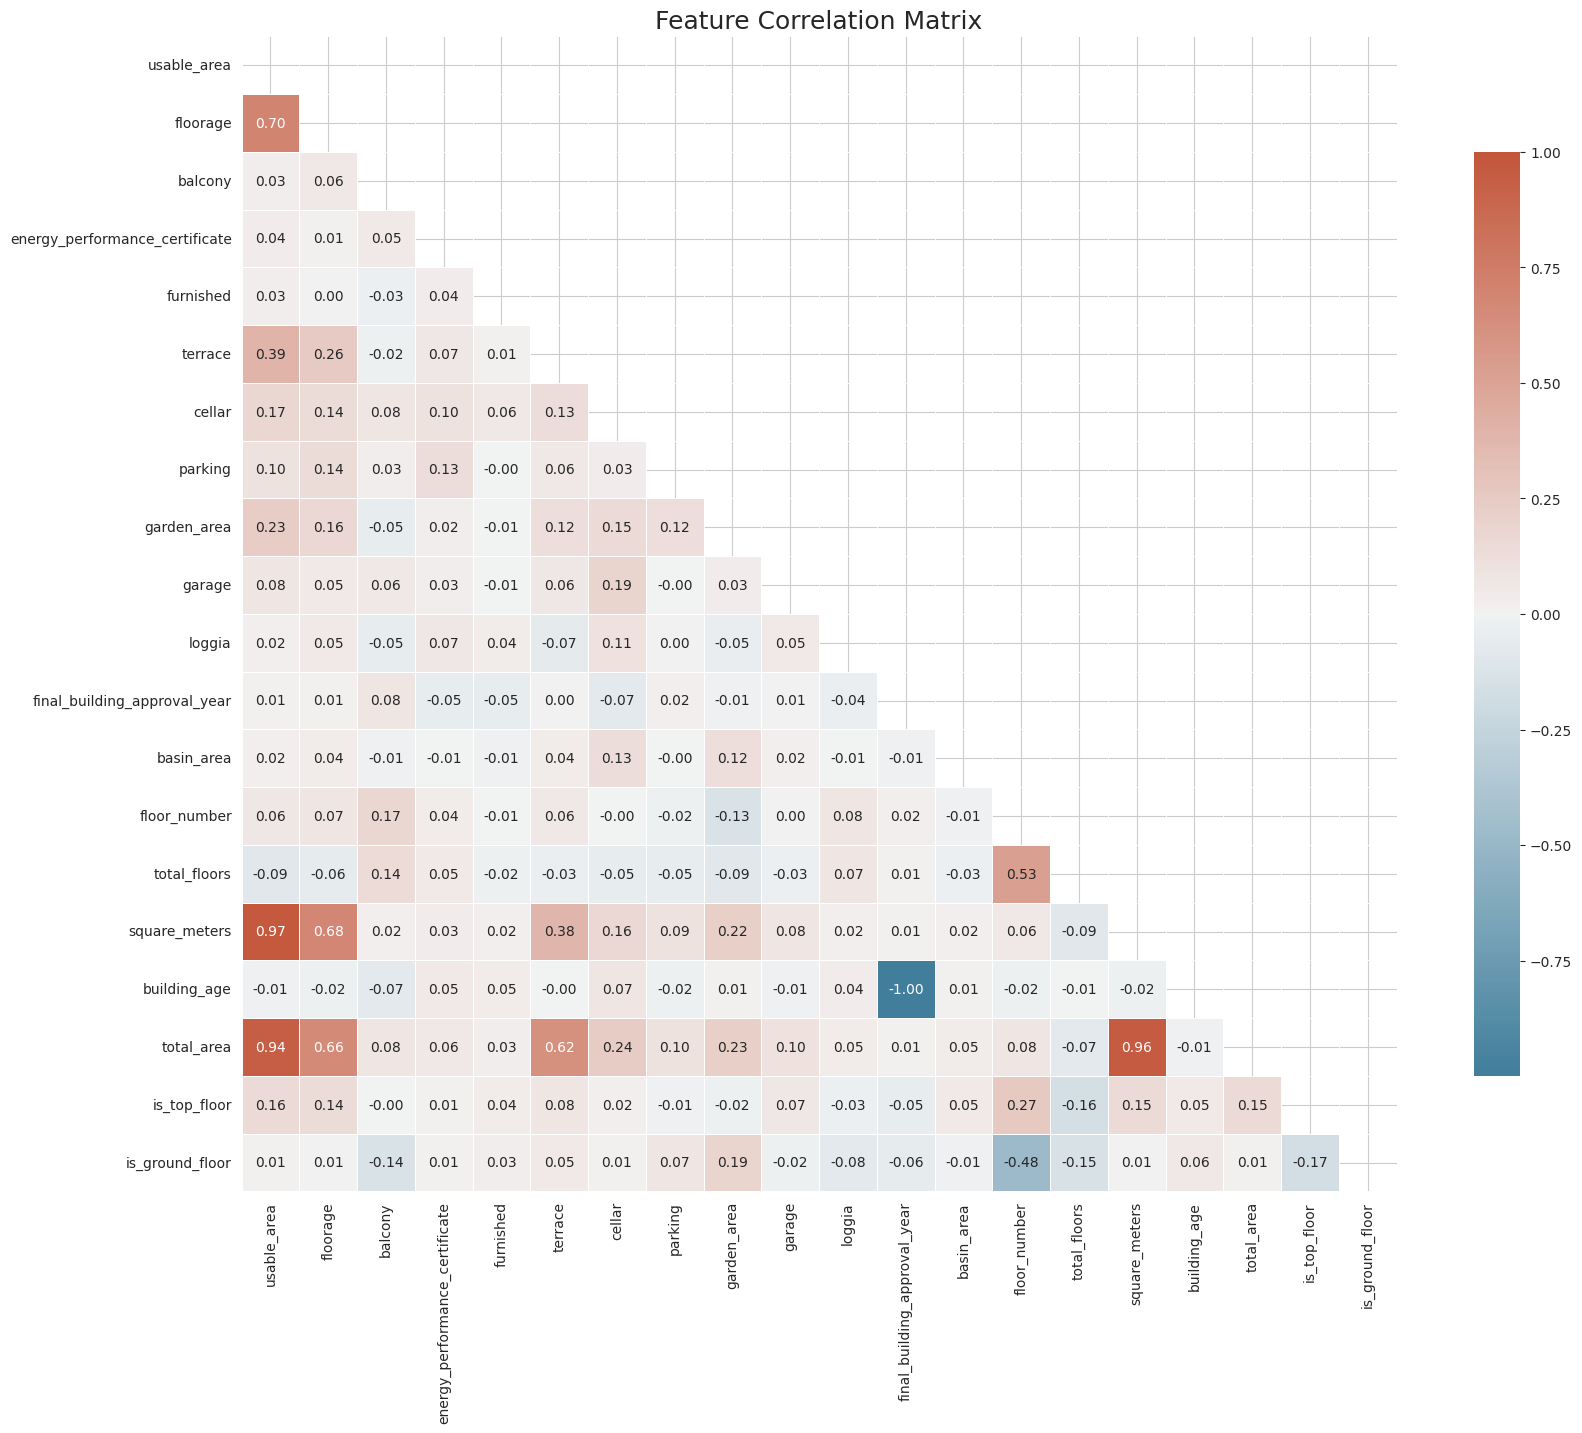


🔍 Found 4 pairs with correlation > 0.9


,Feature1,Feature2,Correlation,Correlation_abs
158,final_building_approval_year,building_age,-0.999553,0.999553
14,usable_area,square_meters,0.974406,0.974406
181,square_meters,total_area,0.955025,0.955025
16,usable_area,total_area,0.938021,0.938021


In [ ]:
# Run correlation check on updated feature set
high_corr_df, updated_corr_matrix = find_highly_correlated_features(
    df=X_train,           # or full dataset if appropriate
    feature_list=numerical,  # or numerical, or features
    target_col='price',       # optional: can sort later
    correlation_threshold=0.9,
    exclude_na_flags=True,
    plot=True
)

# View top correlated pairs
display(high_corr_df)


In [162]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def select_features_by_correlation_and_r2(df, target, high_corr_df, drop_if_lower_r2=True):
    """
    Automatically drop the lower-R² feature from highly correlated pairs.
    """
    to_drop = []
    for _, row in high_corr_df.iterrows():
        f1, f2 = row['Feature1'], row['Feature2']
        r2_f1 = r2_score(y_train, LinearRegression().fit(X_train[[f1]], y_train).predict(X_train[[f1]]))
        r2_f2 = r2_score(y_train, LinearRegression().fit(X_train[[f2]], y_train).predict(X_train[[f2]]))

        print(f"{f1}: R²={r2_f1:.4f}, {f2}: R²={r2_f2:.4f}")

        if drop_if_lower_r2:
            drop_feature = f1 if r2_f1 < r2_f2 else f2
            to_drop.append(drop_feature)
            print(f"Dropping: {drop_feature}")

    return to_drop


In [163]:
features_to_remove = select_features_by_correlation_and_r2(X_train, y_train, high_corr_df)


final_building_approval_year: R²=0.0030, building_age: R²=0.0032
Dropping: final_building_approval_year
usable_area: R²=0.6008, square_meters: R²=0.6348
Dropping: usable_area
square_meters: R²=0.6348, total_area: R²=0.5850
Dropping: total_area
usable_area: R²=0.6008, total_area: R²=0.5850
Dropping: total_area


Based on R2 score let's eliminate 2 features that have high correlation with another feature: total_area and final_building_approval_year

In [164]:
print(numerical)
print(continuous)

['usable_area', 'floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'final_building_approval_year', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'total_area', 'is_top_floor', 'is_ground_floor']
['usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'final_building_approval_year', 'square_meters', 'building_age', 'total_area']


In [165]:
numerical = [f for f in numerical if f not in features_to_remove]
continuous = [f for f in continuous if f not in features_to_remove]

In [166]:
print(numerical)
print(continuous)

['floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'is_top_floor', 'is_ground_floor']
['floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'square_meters', 'building_age']


5.3.2 Categorical variables correlation

High correlation between cadastral_area and district. Due to high cardinality of cadastral_area (~100), and similar predictive power, we retain district and drop cadastral_area to reduce dimensionality and overfitting risk in linear models.

In [167]:
categorical = [x for x in categorical if x != 'cadastral_area']

In [168]:
categorical

['building',
 'property_status',
 'ownership',
 'property_location',
 'water',
 'heating',
 'gas',
 'waste',
 'district',
 'layout']

In [169]:
X_train.shape

(2745, 40)

In [170]:
X_train.columns

Index(['location', 'building', 'property_status', 'ownership',
       'property_location', 'usable_area', 'floorage', 'balcony', 'water',
       'heating', 'gas', 'energy_performance_rating',
       'energy_performance_certificate', 'furnished', 'terrace', 'cellar',
       'parking', 'garden_area', 'garage', 'loggia', 'waste',
       'final_building_approval_year', 'basin_area', 'floor_number',
       'total_floors', 'street', 'district', 'cadastral_area', 'layout',
       'square_meters', 'usable_area_NA', 'floorage_NA',
       'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA',
       'total_area', 'is_top_floor', 'is_ground_floor', 'building_age',
       'energy_performance_rating_numeric'],
      dtype='object')

In [171]:
print(numerical)
print(categorical)

['floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'is_top_floor', 'is_ground_floor']
['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'waste', 'district', 'layout']


In [172]:
 len(numerical)

22

In [173]:
len(categorical)

10

### 5.4 Feature selection

5.4.1 Numerical

We'll try to get a glimple of the feature importance using Mutual info and Lasso importance for Numerical features.

In [174]:
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# === INPUTS ===
X_num = X_train[numerical].copy()  # Already imputed
y = y_train.copy()

# === SCALE X ===
x_scaler = StandardScaler()
X_scaled = pd.DataFrame(x_scaler.fit_transform(X_num), columns=X_num.columns)

# === SCALE y ===
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# === MUTUAL INFO ===
mi = mutual_info_regression(X_num, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X_num.columns, 'Mutual_Info': mi})

# === LASSO ===
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y_scaled)
lasso_df = pd.DataFrame({
    'Feature': X_num.columns,
    'Lasso_Importance': np.abs(lasso.coef_)
})

# === VIF ===
vif_scores = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
vif_df = pd.DataFrame({'Feature': X_num.columns, 'VIF': vif_scores})

# === COMBINE RESULTS ===
num_df = mi_df.merge(lasso_df, on='Feature').merge(vif_df, on='Feature').set_index('Feature')

# === DECISION RULES ===
LASSO_THRESHOLD = 0.01  # Safe now, since y is standardized

# "Drop if weak in both MI and Lasso"
num_df['Recommended_Drop'] = (
    (num_df['Mutual_Info'] < 0.01) &
    (num_df['Lasso_Importance'] < LASSO_THRESHOLD)
)

# VIF warning, not exclusionary
num_df['High_VIF'] = num_df['VIF'] > 10

# === FINAL SELECTION ===
num_keep = num_df[~num_df['Recommended_Drop']].index.tolist()
num_drop = num_df[num_df['Recommended_Drop']].index.tolist()

# === OUTPUT ===
print("\n=== NUMERICAL FEATURE ANALYSIS ===")
print(num_df.sort_values(by='Mutual_Info', ascending=False))
print(f"\n✅ Keep ({len(num_keep)}): {num_keep}")
print(f"\n❌ Drop ({len(num_drop)}): {num_drop}")
print("\n⚠️ High VIF Warning:")
print(num_df[num_df['High_VIF']].sort_values(by='VIF', ascending=False))



=== NUMERICAL FEATURE ANALYSIS ===
                                 Mutual_Info  Lasso_Importance        VIF  \
Feature                                                                     
square_meters                       0.772263          0.781713   2.221925   
floorage                            0.468160          0.000012   2.024561   
balcony                             0.091500          0.020208   1.117369   
terrace                             0.076356          0.000804   1.224370   
floor_number                        0.056201          0.039333   2.263054   
total_floors                        0.055569          0.041973   1.831045   
building_age                        0.052571          0.041121   1.237428   
cellar                              0.046574          0.003189   1.159267   
garden_area                         0.039165          0.003403   1.159702   
usable_area_NA                      0.031085          0.044710  14.093863   
garage                              0.02

['energy_performance_certificate', 'floor_number_NA', 'is_top_floor'] were selected as variables to drop.
'floor_number_NA' has also high VIF value. We'll drop all 3 of them.

In [175]:
features_to_remove = ['energy_performance_certificate', 'floor_number_NA', 'is_top_floor']
continuous = [f for f in continuous if f not in features_to_remove]
numerical = [f for f in numerical if f not in features_to_remove]

In [176]:
numerical

['floorage',
 'balcony',
 'furnished',
 'terrace',
 'cellar',
 'parking',
 'garden_area',
 'garage',
 'loggia',
 'basin_area',
 'floor_number',
 'total_floors',
 'square_meters',
 'usable_area_NA',
 'floorage_NA',
 'final_building_approval_year_NA',
 'total_floors_NA',
 'building_age',
 'is_ground_floor']

5.4.2 Categorical

We'll use Mutual info and ANOVA to decide the importance of categorical values.

In [177]:
from sklearn.feature_selection import f_regression, f_classif
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

X_cat_encoded = X_train[categorical].apply(lambda x: x.astype('category').cat.codes)

# Calculate Mutual Info and ANOVA
mi_scores_cat = mutual_info_regression(X_cat_encoded, y_train, discrete_features=True)
f_scores_cat, p_values_cat = f_regression(X_cat_encoded, y_train)

cat_scores_df = pd.DataFrame({
    'Feature': categorical,
    'Mutual_Info': mi_scores_cat,
    'ANOVA_F': f_scores_cat,
    'ANOVA_p': p_values_cat
}).set_index('Feature')

# Apply stricter keep rule
cat_scores_df['Recommended_Drop'] = (
    (cat_scores_df['Mutual_Info'] < 0.02) &
    (cat_scores_df['ANOVA_p'] > 0.1)
)

cat_keep = cat_scores_df[~cat_scores_df['Recommended_Drop']].index.tolist()
cat_drop = cat_scores_df[cat_scores_df['Recommended_Drop']].index.tolist()

print("\n=== CATEGORICAL FEATURE ANALYSIS ===")
print(cat_scores_df.sort_values(by='Mutual_Info', ascending=False))
print(f"\n✅ Keep ({len(cat_keep)}): {cat_keep}")
print(f"\n❌ Drop ({len(cat_drop)}): {cat_drop}")


=== CATEGORICAL FEATURE ANALYSIS ===
                   Mutual_Info      ANOVA_F        ANOVA_p  Recommended_Drop
Feature                                                                     
layout                0.476693  1700.922515  1.014015e-289             False
property_status       0.134513     0.898601   3.432406e-01             False
building              0.127852    63.477644   2.355319e-15             False
district              0.112116    60.048218   1.293524e-14             False
property_location     0.052258    25.235699   5.399018e-07             False
ownership             0.045122    61.427550   6.517340e-15             False
gas                   0.028770     0.993903   3.188783e-01             False
waste                 0.021716    25.034658   5.986576e-07             False
heating               0.011022    23.737876   1.166653e-06             False
water                 0.009144    10.163066   1.448945e-03             False

✅ Keep (10): ['building', 'property_s

Similarly to numerical features we have 5 candidates to drop but none of them has low score in both MI and ANOVA P values, so we'll keep them all for now and test the model with only recommended features.


### 5.5 Target variable analysis and transformationm

In [178]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import boxcox, yeojohnson
from statsmodels.graphics.gofplots import qqplot
from scipy.stats.mstats import winsorize
from scipy.stats import boxcox, yeojohnson, probplot
from sklearn.preprocessing import PowerTransformer

def plot_distribution(y, title="Original"):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(y, kde=True, ax=ax[0])
    ax[0].set_title(f'{title} - Histogram + KDE')
    sns.boxplot(y=y, ax=ax[1])
    ax[1].set_title(f'{title} - Boxplot')
    qqplot(y, line='s', ax=ax[2])
    ax[2].set_title(f'{title} - QQ Plot')
    plt.tight_layout()
    plt.show()

def transform_target_explorer(y, winsorize=False, winsorize_quantile=0.01):
    """
    Explore and visualize different transformations on the target variable.
    Parameters:
        y: pandas Series (target variable)
        winsorize: bool - whether to include a log+Winsorized version
        winsorize_quantile: float - quantile used for Winsorizing
    """
    assert isinstance(y, pd.Series), "Target must be a pandas Series"

    print(f"\n🔍 Original target distribution:")
    plot_distribution(y, 'Original')

    # Log Transform
    if (y <= 0).any():
        print("⚠️ Log transform skipped due to non-positive values.")
        y_log = None
    else:
        y_log = np.log(y)
        print(f"\n📊 Log-transformed target:")
        plot_distribution(y_log, 'Log')

    # Box-Cox
    if (y <= 0).any():
        print("⚠️ Box-Cox skipped due to non-positive values.")
        y_boxcox = None
    else:
        y_boxcox, lam_boxcox = boxcox(y)
        print(f"\n📊 Box-Cox (λ={lam_boxcox:.3f}):")
        plot_distribution(y_boxcox, f'Box-Cox (λ={lam_boxcox:.3f})')

    # Yeo-Johnson
    pt = PowerTransformer(method='yeo-johnson')
    y_yj = pt.fit_transform(y.values.reshape(-1, 1)).flatten()
    lam_yj = pt.lambdas_[0]
    print(f"\n📊 Yeo-Johnson (λ={lam_yj:.3f}):")
    plot_distribution(y_yj, f'Yeo-Johnson (λ={lam_yj:.3f})')

    # Log + Winsorize
    if winsorize and y_log is not None:
        q_low = y_log.quantile(winsorize_quantile)
        q_high = y_log.quantile(1 - winsorize_quantile)
        y_winsor = y_log.clip(lower=q_low, upper=q_high)
        print(f"\n📊 Log + Winsorized ({int(winsorize_quantile*100)}%):")
        plot_distribution(y_winsor, f'Log + Winsorized ({int(winsorize_quantile*100)}%)')



🔍 Original target distribution:


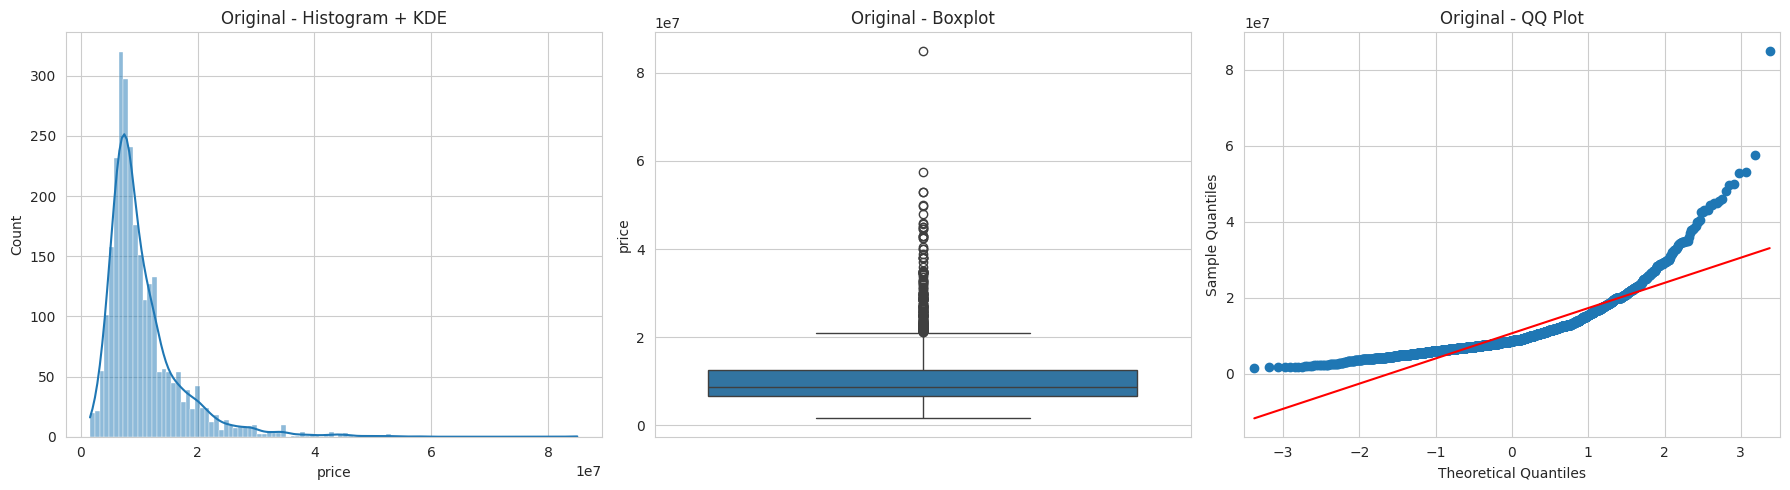


📊 Log-transformed target:


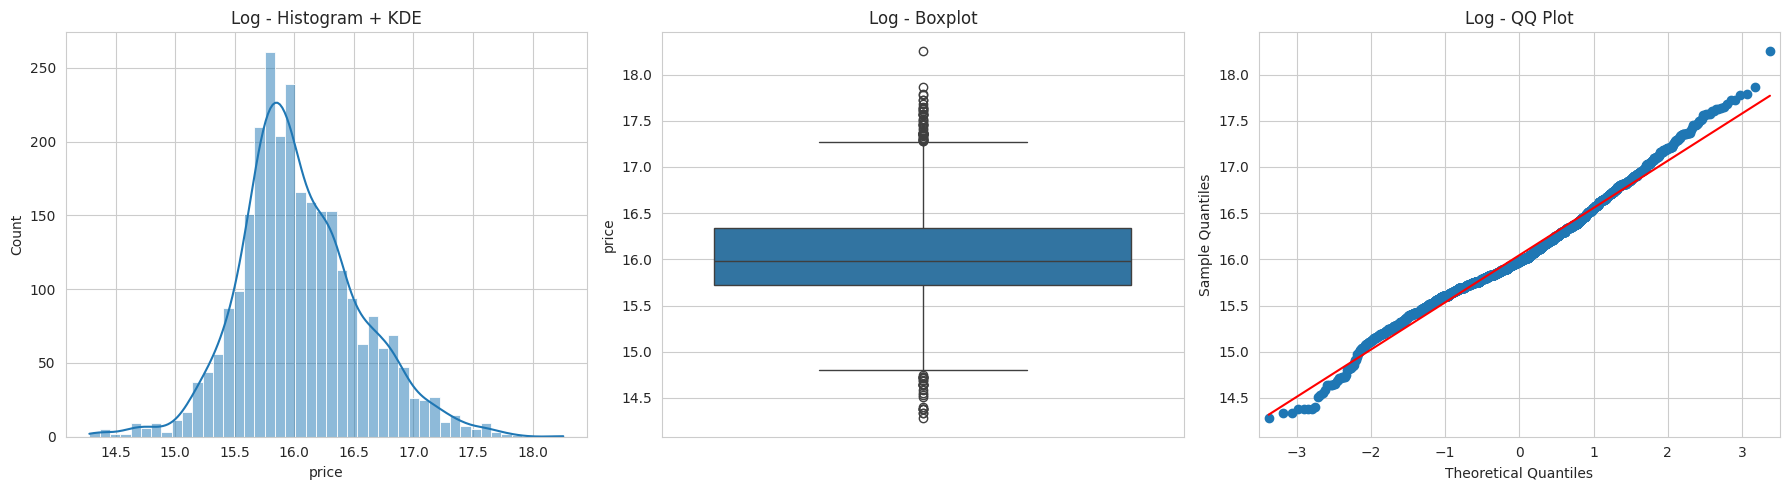


📊 Box-Cox (λ=-0.184):


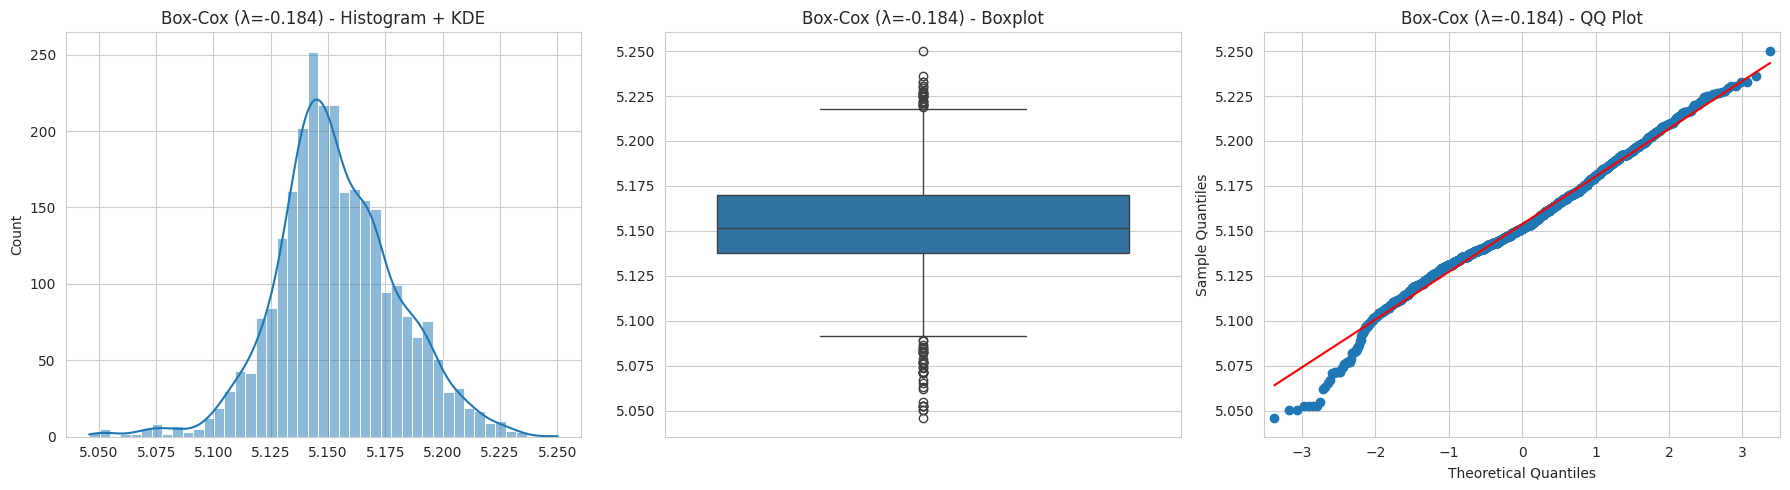


📊 Yeo-Johnson (λ=-0.184):


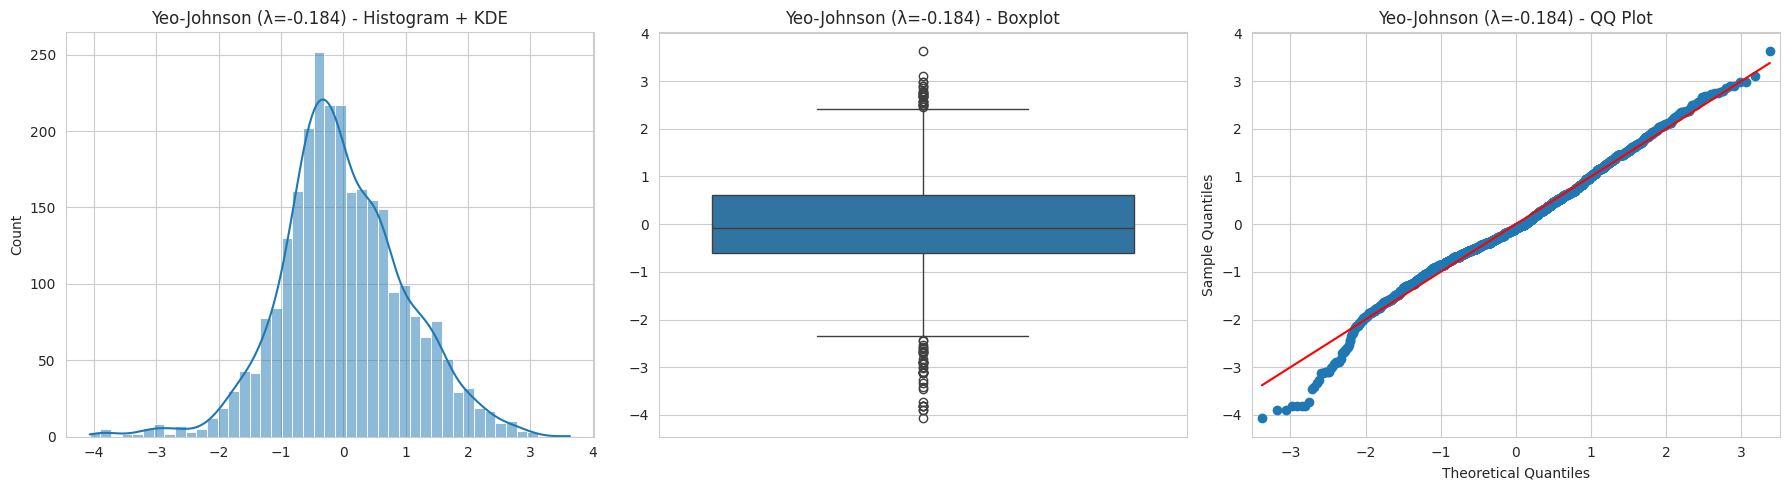

In [ ]:
transform_target_explorer(y_train, winsorize=False)


In [180]:
y_train = np.log(y_train)
y_valid = np.log(y_valid)
y_test = np.log(y_test)


### 5.6 Scaling, normalization and standardization

Standardization is needed because:
- Linear models (OLS, Ridge, Lasso) assume coefficients are comparable. But if one variable is in millions and another in decimals, the scale difference distorts learning and regularization.

- Helps regularization techniques like Ridge/Lasso treat all coefficients fairly.

- It improves numerical stability and convergence for solvers (gradient descent, etc.).

Normalization is useful when:
- The feature is strongly skewed (right/left).

- You want to reduce outlier influence.

- You want better approximation of linearity between feature and target (which linear models love).

- You plan to use models sensitive to feature distribution (e.g., LDA, logistic regression)

In [ ]:
"""

from sklearn.preprocessing import PowerTransformer, StandardScaler

# 1. Normalize skewed data
pt = PowerTransformer(method='yeo-johnson')
X_train[continuous] = pt.fit_transform(X_train[continuous])
X_valid[continuous] = pt.transform(X_valid[continuous])
X_test[continuous]  = pt.transform(X_test[continuous])

# 2. Standardize
scaler = StandardScaler()
X_train[continuous] = scaler.fit_transform(X_train[continuous])
X_valid[continuous] = scaler.transform(X_valid[continuous])
X_test[continuous]  = scaler.transform(X_test[continuous])
"""


"\n\nfrom sklearn.preprocessing import PowerTransformer, StandardScaler\n\n# 1. Normalize skewed data\npt = PowerTransformer(method='yeo-johnson')\nX_train[continuous] = pt.fit_transform(X_train[continuous])\nX_valid[continuous] = pt.transform(X_valid[continuous])\nX_test[continuous]  = pt.transform(X_test[continuous])\n\n# 2. Standardize\nscaler = StandardScaler()\nX_train[continuous] = scaler.fit_transform(X_train[continuous])\nX_valid[continuous] = scaler.transform(X_valid[continuous])\nX_test[continuous]  = scaler.transform(X_test[continuous])\n"

In [ ]:
"""
import pandas as pd
import numpy as np

from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# === INPUTS ===
# Provide these from your earlier code
# continuous = [...your list of continuous numeric features...]
# categorical = [...your list of categorical features...]
# num_keep = [...your filtered numeric features to keep...]
# cat_keep = [...your filtered categorical features to keep...]

# === NUMERICAL PIPELINE ===
# chain of multiple transformers
# first normalizes skewed data (PowerTransformer), then standardize features (mean = 0, std = 1)
num_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

# === CATEGORICAL PIPELINE ===
# just a single transformer - One-Hot encoder
cat_pipeline = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# === COMBINED PREPROCESSOR ===
# Apply the numerical pipeline to the columns in continuous, apply the categorical encoder to the columns in categorical
# Then it stitches together the outputs (numerical + encoded categoricals) into one combined NumPy array.
# We can then .fit_transform() this preprocessor on our training set, and just .transform() it on validation/test sets.
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical),
    ('cat', cat_pipeline, categorical)
])

# === FIT ON TRAINING DATA ===
X_train_full = preprocessor.fit_transform(X_train)
X_valid_full = preprocessor.transform(X_valid)
X_test_full  = preprocessor.transform(X_test)

# === GET FEATURE NAMES AFTER TRANSFORMATIONS ===
num_features = numerical  # Names stay the same
cat_encoder = preprocessor.named_transformers_['cat']
ohe_features = cat_encoder.get_feature_names_out(categorical)

full_feature_names = num_features + list(ohe_features)

# === CONVERT TO DATAFRAMES ===
X_train_full = pd.DataFrame(X_train_full, columns=full_feature_names, index=X_train.index)
X_valid_full = pd.DataFrame(X_valid_full, columns=full_feature_names, index=X_valid.index)
X_test_full  = pd.DataFrame(X_test_full, columns=full_feature_names, index=X_test.index)

# === OPTIONAL: REDUCED FEATURE SET ===
# Filter one-hot features to only those from selected cat_keep
# This correctly filters only encoded categorical features from cat_keep
ohe_keep = [col for col in ohe_features if any(col.startswith(cat + '_') for cat in cat_keep)]

# Now combine with numerical features
features_keep = num_keep + ohe_keep

missing = [f for f in features_keep if f not in X_train_full.columns]
print("Missing from X_train_full:", missing)

# Select reduced sets
X_train_reduced = X_train_full[features_keep].copy()
X_valid_reduced = X_valid_full[features_keep].copy()
X_test_reduced  = X_test_full[features_keep].copy()

"""

'\nimport pandas as pd\nimport numpy as np\n\nfrom sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.compose import ColumnTransformer\n\n# === INPUTS ===\n# Provide these from your earlier code\n# continuous = [...your list of continuous numeric features...]\n# categorical = [...your list of categorical features...]\n# num_keep = [...your filtered numeric features to keep...]\n# cat_keep = [...your filtered categorical features to keep...]\n\n# === NUMERICAL PIPELINE ===\n# chain of multiple transformers\n# first normalizes skewed data (PowerTransformer), then standardize features (mean = 0, std = 1)\nnum_pipeline = Pipeline([\n    (\'power\', PowerTransformer(method=\'yeo-johnson\')),\n    (\'scale\', StandardScaler())\n])\n\n# === CATEGORICAL PIPELINE ===\n# just a single transformer - One-Hot encoder\ncat_pipeline = OneHotEncoder(drop=\'first\', sparse_output=False, handle_unknown=\'ignore\')\n\n# === CO

In [183]:
X_train.shape

(2745, 40)

In [184]:
print(len(numerical), len(categorical))
print(numerical, categorical)

19 10
['floorage', 'balcony', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'total_floors_NA', 'building_age', 'is_ground_floor'] ['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'waste', 'district', 'layout']


In [185]:
# === FINAL FEATURE SELECTION ===
selected_features = numerical + categorical

# Limit data to selected features
X_train = X_train[selected_features].copy()
X_valid = X_valid[selected_features].copy()
X_test  = X_test[selected_features].copy()


In [186]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# === FINAL FEATURE SETS ===
# Use only selected features after analysis
numerical = num_keep
categorical = cat_keep

# === NUMERICAL PIPELINE ===
num_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

# === CATEGORICAL PIPELINE ===
#cat_encoder.fit(pd.concat([X_train, X_valid, X_test])[categorical])
cat_pipeline = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# === COMBINED PREPROCESSOR ===
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical),
    ('cat', cat_pipeline, categorical)
])


# === SAVE ORIGINAL INDEXES BEFORE TRANSFORMATION ===
X_train_index = X_train.index
X_valid_index = X_valid.index
X_test_index  = X_test.index

# === FIT AND TRANSFORM ===
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test  = preprocessor.transform(X_test)

# === FEATURE NAMES ===
cat_encoder = preprocessor.named_transformers_['cat']
ohe_features = cat_encoder.get_feature_names_out(categorical)
all_feature_names = numerical + list(ohe_features)

# === CONVERT TO DATAFRAMES ===
X_train = pd.DataFrame(X_train, columns=all_feature_names, index=X_train_index)
X_valid = pd.DataFrame(X_valid, columns=all_feature_names, index=X_valid_index)
X_test  = pd.DataFrame(X_test,  columns=all_feature_names, index=X_test_index)


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# Same but modular and reusable
"""
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd

def preprocess_features(X_train, X_valid, X_test, num_keep, cat_keep):
    ""
    Transforms training, validation, and test sets using:
      - Power + Standard scaling for numerical features
      - One-hot encoding for categorical features
    Parameters:
        X_train, X_valid, X_test: pandas DataFrames
        num_keep: list of selected numerical features
        cat_keep: list of selected categorical features
    Returns:
        X_train_transformed, X_valid_transformed, X_test_transformed, feature_names
    ""
    # === Define pipelines ===
    num_pipeline = Pipeline([
        ('power', PowerTransformer(method='yeo-johnson')),
        ('scale', StandardScaler())
    ])

    cat_pipeline = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

    # === Combine ===
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, num_keep),
        ('cat', cat_pipeline, cat_keep)
    ])

    # === Fit on train, transform all ===
    X_train_array = preprocessor.fit_transform(X_train)
    X_valid_array = preprocessor.transform(X_valid)
    X_test_array  = preprocessor.transform(X_test)

    # === Feature names ===
    cat_encoder = preprocessor.named_transformers_['cat']
    ohe_features = cat_encoder.get_feature_names_out(cat_keep)
    all_feature_names = num_keep + list(ohe_features)

    # === Convert to DataFrames ===
    X_train_out = pd.DataFrame(X_train_array, columns=all_feature_names, index=X_train.index)
    X_valid_out = pd.DataFrame(X_valid_array, columns=all_feature_names, index=X_valid.index)
    X_test_out  = pd.DataFrame(X_test_array, columns=all_feature_names, index=X_test.index)

    return X_train_out, X_valid_out, X_test_out, all_feature_names


X_train, X_valid, X_test, feature_names = preprocess_features(
    X_train=X_train,
    X_valid=X_valid,
    X_test=X_test,
    num_keep=num_keep,
    cat_keep=cat_keep
)
"""

'\nfrom sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.compose import ColumnTransformer\nimport pandas as pd\n\ndef preprocess_features(X_train, X_valid, X_test, num_keep, cat_keep):\n    ""\n    Transforms training, validation, and test sets using:\n      - Power + Standard scaling for numerical features\n      - One-hot encoding for categorical features\n    Parameters:\n        X_train, X_valid, X_test: pandas DataFrames\n        num_keep: list of selected numerical features\n        cat_keep: list of selected categorical features\n    Returns:\n        X_train_transformed, X_valid_transformed, X_test_transformed, feature_names\n    ""\n    # === Define pipelines ===\n    num_pipeline = Pipeline([\n        (\'power\', PowerTransformer(method=\'yeo-johnson\')),\n        (\'scale\', StandardScaler())\n    ])\n\n    cat_pipeline = OneHotEncoder(drop=\'first\', sparse_output=False, handle_unknown=\'ignore

In [188]:
X_valid.shape

(687, 75)

In [189]:
X_train.shape

(2745, 75)

In [190]:
X_valid.shape

(687, 75)

In [191]:
X_train.columns

Index(['floorage', 'balcony', 'furnished', 'terrace', 'cellar', 'parking',
       'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number',
       'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA',
       'final_building_approval_year_NA', 'total_floors_NA', 'building_age',
       'is_ground_floor', 'building_Framed structure', 'building_Missing',
       'building_Mixed', 'building_Panel', 'building_Stone', 'building_Wooden',
       'property_status_In good condition', 'property_status_In renovation',
       'property_status_In very good condition', 'property_status_Missing',
       'property_status_New development projects', 'property_status_New homes',
       'property_status_Renovated', 'property_status_Under construction',
       'ownership_Missing', 'ownership_Personal',
       'ownership_State-owned/municipal',
       'property_location_Housing development', 'property_location_Missing',
       'property_location_Municipality centre',
       'property_locatio

# 6 Model Feature Selection & Preparation

In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_selection import RFE, SelectFromModel, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning
import warnings
import time

def feature_selection_pipeline(X, y, tolerance=0.01, include_permutation=False, verbose=True):
    """
    Feature selection using RFE, Ridge SFM, and Sequential Feature Selectors (FWD/BKWD).
    Returns top features selected most frequently across selectors.
    """

    # --- Setup ---
    start = time.time()
    warnings.simplefilter("ignore", ConvergenceWarning)
    features = X.columns.tolist()
    max_features = len(features)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    if verbose:
        print(f"\n🚀 Starting feature selection on {max_features} features...\n")

    # --- Step 1: RFE-Based Feature Count Selection ---
    scores = []

    for n in range(5, min(max_features + 1, 40)):  # avoid full range for speed
        rfe = RFE(LinearRegression(), n_features_to_select=n)
        rfe.fit(X, y)
        selected = X.columns[rfe.support_]
        score = cross_val_score(LinearRegression(), X[selected], y, cv=cv, scoring='r2', n_jobs=-1).mean()
        scores.append(score)

    best_score = max(scores)
    for i, score in enumerate(scores):
        if best_score - score <= tolerance:
            n_opt = i + 5  # offset for start at 5
            break

    if verbose:
        print(f"[✔] Optimal number of features (RFE): {n_opt}")

        plt.figure(figsize=(8, 5))
        plt.plot(range(5, 5 + len(scores)), scores, label="CV R²")
        plt.axvline(n_opt, color='r', linestyle='--', label=f"Selected: {n_opt}")
        plt.xlabel("Number of Features")
        plt.ylabel("CV R² Score")
        plt.title("RFE Feature Count Selection")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

    selected_all = []

    # --- Step 2: RFE Final ---
    rfe = RFE(LinearRegression(), n_features_to_select=n_opt)
    rfe.fit(X, y)
    selected_rfe = X.columns[rfe.support_].tolist()
    selected_all += selected_rfe
    if verbose:
        print(f"[✔] RFE selected: {selected_rfe}")

    # --- Step 3: Ridge + SFM ---
    ridge = RidgeCV(alphas=np.logspace(-6, 6, 5), cv=cv)
    ridge.fit(X, y)
    importance = np.abs(ridge.coef_)
    threshold = np.sort(importance)[-n_opt] + 1e-6
    sfm = SelectFromModel(ridge, threshold=threshold, prefit=True)
    selected_sfm = X.columns[sfm.get_support()].tolist()
    selected_all += selected_sfm
    if verbose:
        print(f"[✔] Ridge SFM selected: {selected_sfm}")

    # --- Step 4: SFS (Forward and Backward) ---
    sfs_fwd = SequentialFeatureSelector(ridge, n_features_to_select=n_opt, direction="forward", cv=cv, scoring='r2', n_jobs=-1)
    sfs_fwd.fit(X, y)
    selected_fwd = X.columns[sfs_fwd.get_support()].tolist()
    selected_all += selected_fwd

    sfs_bkwd = SequentialFeatureSelector(ridge, n_features_to_select=n_opt, direction="backward", cv=cv, scoring='r2', n_jobs=-1)
    sfs_bkwd.fit(X, y)
    selected_bkwd = X.columns[sfs_bkwd.get_support()].tolist()
    selected_all += selected_bkwd

    if verbose:
        print(f"[✔] SFS Forward selected: {selected_fwd}")
        print(f"[✔] SFS Backward selected: {selected_bkwd}")

    # --- Step 5: Voting ---
    counter = Counter(selected_all)
    top_features = [feat for feat, count in counter.most_common(n_opt)]

    if verbose:
        print(f"\n[🏁] Final Top {n_opt} Features by Voting:\n", top_features)

    # --- Step 6: Optional Permutation Importance ---
    if include_permutation:
        model = LinearRegression()
        model.fit(X[top_features], y)
        result = permutation_importance(model, X[top_features], y, scoring='r2', n_repeats=30, random_state=42)
        sorted_idx = result.importances_mean.argsort()[::-1]
        print("\n[🧪] Permutation Importance:")
        for i in sorted_idx:
            print(f"{top_features[i]}: {result.importances_mean[i]:.4f}")

    if verbose:
        duration = time.time() - start
        print(f"\n⏱️ Feature selection completed in {duration:.2f} seconds.")

    return top_features



🚀 Starting feature selection on 75 features...

[✔] Optimal number of features (RFE): 24


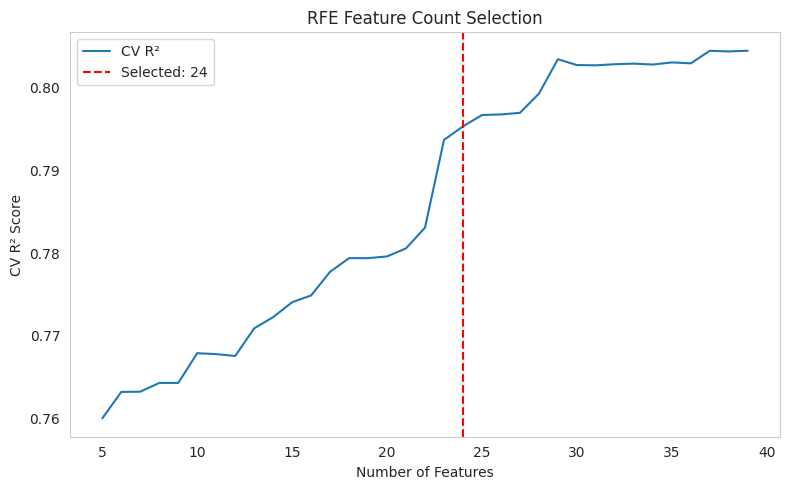

[✔] RFE selected: ['square_meters', 'usable_area_NA', 'building_Panel', 'property_status_In very good condition', 'property_status_New development projects', 'property_status_New homes', 'property_status_Under construction', 'ownership_Personal', 'ownership_State-owned/municipal', 'waste_other', 'district_Praha 1', 'district_Praha 10', 'district_Praha 14', 'district_Praha 2', 'district_Praha 3', 'district_Praha 4', 'district_Praha 5', 'district_Praha 6', 'district_Praha 7', 'district_Praha 8', 'district_Praha 9', 'layout_4+kt', 'layout_5+kt', 'layout_unusual']
[✔] Ridge SFM selected: ['square_meters', 'building_Panel', 'property_status_In very good condition', 'property_status_New development projects', 'property_status_New homes', 'property_status_Renovated', 'property_status_Under construction', 'ownership_Personal', 'ownership_State-owned/municipal', 'waste_other', 'district_Praha 1', 'district_Praha 2', 'district_Praha 3', 'district_Praha 5', 'district_Praha 6', 'district_Praha 7',

In [ ]:
RUN_HEAVY = False  # Set to True to rerun the pipeline

if RUN_HEAVY:
    top_features = feature_selection_pipeline(X_train, y_train, include_permutation=True)

    # Save result
    pd.Series(top_features).to_csv("top_features.csv", index=False)
else:
    # Load from saved file
    top_features = pd.read_csv("top_features.csv").squeeze().tolist()


In [ ]:
top_features

# 7. Model selection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")

# === Define your models and param grids ===
models = {
    "Linear": (LinearRegression(), {
        "fit_intercept": [True]
    }),
    "Ridge": (Ridge(), {
        "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10],
        "solver": ['auto', 'saga']
    }),
    "Lasso": (Lasso(), {
        "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
        "max_iter": [1000, 5000]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.0001, 0.001, 0.01],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "Huber": (HuberRegressor(), {
        "alpha": [0.0001, 0.001, 0.01],
        "epsilon": [1.35, 1.75, 2.0],
        "max_iter": [1000]
    }),
    "GBR": (GradientBoostingRegressor(), {
        "n_estimators": [100, 300],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0],
        "min_samples_split": [2, 5]
    })
}

# === Run GridSearchCV on all models ===
results = []

for name, (model, params) in models.items():
    print(f"🔍 Training: {name}")
    grid = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    r2 = r2_score(y_test, preds)

    results.append({
        "model": name,
        "best_score": grid.best_score_,
        "test_r2": r2,
        "best_params": grid.best_params_
    })

# === Leaderboard ===
leaderboard = pd.DataFrame(results).sort_values(by='test_r2', ascending=False)
print("\n🏆 Model Leaderboard (Sorted by R² on Test Set):")
print(leaderboard.to_string(index=False))


🔍 Training: Linear
🔍 Training: Ridge
🔍 Training: Lasso
🔍 Training: ElasticNet
🔍 Training: Huber
🔍 Training: GBR

🏆 Model Leaderboard (Sorted by R² on Test Set):
     model  best_score  test_r2                                                                                           best_params
       GBR    0.842104 0.837534 {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.8}
     Huber    0.508561 0.835796                                                     {'alpha': 0.01, 'epsilon': 2.0, 'max_iter': 1000}
     Lasso    0.810263 0.827913                                                                   {'alpha': 0.0001, 'max_iter': 1000}
ElasticNet    0.810543 0.826700                                                                    {'alpha': 0.0001, 'l1_ratio': 0.1}
     Ridge    0.810541 0.826524                                                                      {'alpha': 0.1, 'solver': 'auto'}
    Linear    0.810508 0.826384    

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score
import joblib
import time
import os

# === PATHS ===
drive_path = "/content/drive/My Drive/Colab Notebooks"
model_path = os.path.join(drive_path, "models")
os.makedirs(model_path, exist_ok=True)  # Create models/ directory if not exists

# === SETTINGS ===
RANDOM_SEED = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# === MODELS + PARAMETERS ===
models = {
    'Linear': (LinearRegression(), {
        'fit_intercept': [True]
    }),
    'Ridge': (Ridge(), {
        'alpha': [0.01, 0.1, 1, 10, 100],
        'solver': ['auto', 'cholesky', 'svd']
    }),
    'Lasso': (Lasso(), {
        'alpha': [0.01, 0.1, 1, 10],
        'max_iter': [1000, 5000],
    }),
    'ElasticNet': (ElasticNet(), {
        'alpha': [0.01, 0.1, 1],
        'l1_ratio': [0.1, 0.5, 0.9],
        'max_iter': [1000, 5000]
    }),
    'Huber': (HuberRegressor(), {
        'epsilon': [1.35, 1.5, 1.75],
        'alpha': [0.0001, 0.001, 0.01],
        'max_iter': [100, 500]
    }),
    'GBR': (GradientBoostingRegressor(random_state=RANDOM_SEED), {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    })
}

# === RESULTS STORAGE ===
results = []

# === TRAINING LOOP ===
X = X_train[top_features]
y = y_train

for name, (model, param_grid) in models.items():
    print(f"\n🔍 {name}")
    pipe = Pipeline([
        ('model', model)
    ])

    grid = GridSearchCV(pipe, param_grid={'model__' + k: v for k, v in param_grid.items()},
                        cv=cv, scoring='r2', n_jobs=-1)

    start = time.time()
    grid.fit(X, y)
    duration = time.time() - start

    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_

    results.append({
        'model': name,
        'best_score': best_score,
        'best_params': best_params,
        'fit_time_sec': duration
    })

    # Save model
    joblib.dump(best_model, f"{model_path}/{name}_model.pkl")

# === RESULTS TABLE ===
results_df = pd.DataFrame(results).sort_values(by="best_score", ascending=False)
print("\n🏆 Model Comparison:")
print(results_df)

# Save results
results_df.to_csv(os.path.join(drive_path, "model_comparison.csv"), index=False)

# === TEST PERFORMANCE ===
X_test_final = X_test[top_features]
ridge_model_path = os.path.join(model_path, "Ridge_model.pkl")
y_test_pred = joblib.load(ridge_model_path).predict(X_test_final)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\n📈 Final Ridge R² on test set: {test_r2:.4f}")



🔍 Linear

🔍 Ridge

🔍 Lasso

🔍 ElasticNet

🔍 Huber

🔍 GBR

🏆 Model Comparison:
        model  best_score                                        best_params  \
5         GBR    0.820240  {'model__learning_rate': 0.1, 'model__max_dept...   
1       Ridge    0.797264    {'model__alpha': 0.01, 'model__solver': 'auto'}   
0      Linear    0.797264                     {'model__fit_intercept': True}   
4       Huber    0.791908  {'model__alpha': 0.01, 'model__epsilon': 1.75,...   
3  ElasticNet    0.789260  {'model__alpha': 0.01, 'model__l1_ratio': 0.1,...   
2       Lasso    0.746346    {'model__alpha': 0.01, 'model__max_iter': 1000}   

   fit_time_sec  
5     17.350364  
1      0.656758  
0      3.256446  
4      8.247936  
3      0.716001  
2      0.392192  

📈 Final Ridge R² on test set: 0.8076


In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score
import joblib
import time

# === SETTINGS ===
RANDOM_SEED = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# === MODELS + PARAMETERS ===
models = {
    'Linear': (LinearRegression(), {
        'fit_intercept': [True]
    }),
    'Ridge': (Ridge(), {
        'alpha': [0.01, 0.1, 1, 10, 100],
        'solver': ['auto', 'cholesky', 'svd']
    }),
    'Lasso': (Lasso(), {
        'alpha': [0.01, 0.1, 1, 10],
        'max_iter': [1000, 5000],
    }),
    'ElasticNet': (ElasticNet(), {
        'alpha': [0.01, 0.1, 1],
        'l1_ratio': [0.1, 0.5, 0.9],
        'max_iter': [1000, 5000]
    }),
    'Huber': (HuberRegressor(), {
        'epsilon': [1.35, 1.5, 1.75],
        'alpha': [0.0001, 0.001, 0.01],
        'max_iter': [100, 500]
    }),
    'GBR': (GradientBoostingRegressor(random_state=RANDOM_SEED), {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    })
}

# === RESULTS STORAGE ===
results = []

# === TRAINING LOOP ===
X = X_train[top_features]
y = y_train

for name, (model, param_grid) in models.items():
    print(f"\n🔍 {name}")
    pipe = Pipeline([
        ('model', model)
    ])

    grid = GridSearchCV(pipe, param_grid={'model__' + k: v for k, v in param_grid.items()},
                        cv=cv, scoring='r2', n_jobs=-1)

    start = time.time()
    grid.fit(X, y)
    duration = time.time() - start

    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_

    results.append({
        'model': name,
        'best_score': best_score,
        'best_params': best_params,
        'fit_time_sec': duration
    })

    # Save model
    joblib.dump(best_model, f"models/{name}_model.pkl")

# === RESULTS TABLE ===
results_df = pd.DataFrame(results).sort_values(by="best_score", ascending=False)
print("\n🏆 Model Comparison:")
print(results_df)

# === TEST PERFORMANCE ===
X_test_final = X_test[top_features]
y_test_pred = joblib.load("models/Ridge_model.pkl").predict(X_test_final)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\n📈 Final Ridge R² on test set: {test_r2:.4f}")



🔍 Linear


FileNotFoundError: [Errno 2] No such file or directory: 'models/Linear_model.pkl'